# Machine-Learned Risk Premia: a Unified Simulation Study

**Scope.** This notebook consolidates eight exploratory notebooks (`1st-step` to `8th-step`) into one
reproducible study with a single, tested code base. Part I studies the *inverse* of the constrained
Markowitz problem: given the portfolio an investor holds, which expected returns rationalise it, how
well can that inverse be learned, and does the learned inverse improve out-of-sample decisions?
Part II asks whether tree ensembles trained under different loss functions recover a known
Merton-type risk premium from returns alone.

**Contributions of this consolidation**

1. One library (`mmlab`) replaces eleven copy-pasted variants of the simulator, optimiser, KKT inverse,
   surrogate trainer and evaluation battery. Every function has unit tests (`tests/test_mmlab.py`);
   the notebook embeds the identical source and a test proves it has not drifted.
2. Two modelling errors of the source notebooks are corrected and documented (`INCONSISTENCIES.md`):
   the "Merton-structural" random forest was trained on the ground truth, and the Ornstein-Uhlenbeck
   volatility of the monthly study was mis-calibrated so that the premium sat at a clipping floor.
3. The forward optimiser is polished on its active set so that the KKT inverse is exact to machine
   precision, which turns the "exact inverse" claim into a testable null (it is tested).
4. All comparisons share one DGP menu, one constraint set (`sum w = 1`, `-0.5 <= w <= 1`), one
   evaluation protocol and one colour-blind-safe visual language.

**How to run.** `python build_notebook.py && python run_notebook.py`. Set `MMLAB_FAST=1` for a
smoke run (minutes). Every figure is written to `outputs/` as PNG (300 dpi) and PDF, every table as CSV.

**Reading guide.** Code cells marked *Library* define the machinery; experiment cells call it. Result
paragraphs are generated from the numbers in the run, so text and figures cannot disagree.

## Provenance: the eight source notebooks

| Source | Unique content | Where it lives here |
|---|---|---|
| 1st step | forward Markowitz, vectorised KKT inverse, two-headed surrogate, OOS battery, Bonferroni sweep, Newey-West | Sections 2, 3, 4, 5 |
| 2nd step | CRRA vs mean-variance through one implied-return lens, (eta, gamma) sweep, corner bridge | Section 7 |
| 3rd step | cap sweep of learnability, identifiability family, one-factor DGP | Sections 3, 4, 6 |
| 4th step | Student-t / skew-normal / jump-mixture DGPs, log vs arithmetic panel | Section 6 |
| 5th step | (eta, gamma) sweep under heavy tails | Section 7 |
| 6th step | GBM vs skew-normal pictures, implied-return dispersion | Sections 2, 6 |
| 7th step | random-forest loss functions for premium recovery, GARCH | Section 9 |
| 8th step | OU volatility, monthly aggregation, SDF-weighted forest | Section 10 |

Twenty-one cross-notebook inconsistencies and twelve modelling issues were found; the full audit
with resolutions is in `INCONSISTENCIES.md`. Numbers therefore differ from the source notebooks;
every qualitative claim of notebooks 1 to 4 is re-tested below.

## 1. Configuration and library

In [1]:
import os, sys, time, math, json, pathlib, subprocess, warnings

FAST = os.environ.get("MMLAB_FAST", "0") == "1"
OUT = pathlib.Path("outputs"); OUT.mkdir(exist_ok=True)
BASE_CAP, BASE_ETA = 0.5, 5.0          # short cap and risk aversion used wherever one value is needed

CFG = dict(
    n_train_universes=120, etas_train=(1.0, 5.0, 10.0), caps=[0.0, 0.1, 0.25, 0.5, 1.0, None],
    n_main=400, eta_sweep=[1.0, 2.0, 5.0, 10.0, 20.0], n_eta=200, n_robust=300, n_shape=50,
    crra_etas=[1.0, 2.0, 5.0, 10.0, 20.0], crra_gammas=[1.0, 2.0, 5.0, 10.0, 20.0],
    n_crra_gauss=200, n_crra_dgp=150, n_dispersion=500,
    n_reps_daily=20, T_daily=5000, n_reps_monthly=30, T_monthly=252 * 60, kappas=[0.5, 1.0, 2.0, 4.0],
    rf_trees=300,
)
if FAST:
    CFG.update(n_train_universes=30, caps=[0.0, 0.5, None], n_main=40, eta_sweep=[1.0, 5.0, 20.0], n_eta=20,
               n_robust=30, n_shape=10, crra_etas=[1.0, 5.0, 10.0], crra_gammas=[2.0, 10.0, 20.0],
               n_crra_gauss=12, n_crra_dgp=8, n_dispersion=40, n_reps_daily=2, T_daily=2000,
               n_reps_monthly=2, T_monthly=252 * 25, kappas=[0.5, 4.0], rf_trees=40)

T_START = time.time()
def elapsed():
    return f"[{time.time() - T_START:6.0f} s]"
print("mode:", "FAST smoke run" if FAST else "FULL publication run")

mode: FULL publication run


#### Library: imports and constants

In [2]:
from __future__ import annotations

import inspect
import math
import warnings
from dataclasses import dataclass, field
from typing import Callable, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import cvxpy as cp
from scipy import stats
from scipy.stats import skewnorm
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import HuberRegressor, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

TRADING_DAYS = 252
DT = 1.0 / TRADING_DAYS
ANN_PCT = TRADING_DAYS * 100.0          # daily simple return -> annualised percent
BINDING_TOL = 1e-6

#### Library: data-generating processes (return panels)

In [3]:
@dataclass
class Panel:
    """A simulated return panel plus whatever ground truth the DGP knows."""

    returns: np.ndarray                      # (num_stocks, num_days) simple returns
    name: str = "panel"
    true_mean: Optional[np.ndarray] = None   # (num_stocks,) E[simple daily return]
    prices: Optional[np.ndarray] = None      # (num_stocks, num_days + 1) if the DGP has prices
    params: Dict[str, np.ndarray] = field(default_factory=dict)

    @property
    def num_stocks(self) -> int:
        return self.returns.shape[0]

    @property
    def num_days(self) -> int:
        return self.returns.shape[1]

    def sample_moments(self) -> Tuple[np.ndarray, np.ndarray]:
        """Sample mean vector and covariance matrix of the daily returns."""
        return self.returns.mean(axis=1), np.cov(self.returns)

    def window(self, start: int, stop: int) -> "Panel":
        """Sub-panel on days [start, stop)."""
        return Panel(self.returns[:, start:stop], self.name, self.true_mean, None, self.params)

    def log_returns(self) -> "Panel":
        """The same paths expressed as log returns (identical shocks, no re-simulation)."""
        return Panel(np.log1p(self.returns), self.name + " (log)", None, self.prices, self.params)


def simulate_gbm(num_stocks: int = 10, num_days: int = 100, seed: int = 0,
                 s0_range=(10.0, 500.0), mu_range=(0.01, 1.0), sigma_range=(0.10, 1.0)) -> Panel:
    """Independent GBM price paths, exact discretisation on the daily grid.

    ``S_k = S0 * exp(sum_{j<=k} [(mu - sigma^2/2) dt + sigma sqrt(dt) z_j])``, so the price at
    day 0 is exactly ``S0`` and drift and diffusion share one clock (fixes NB1/3/4/5).
    The true expected *simple* daily return is ``exp(mu dt) - 1`` (fixes NB1).
    """
    rng = np.random.default_rng(seed)
    s0 = rng.uniform(*s0_range, num_stocks)
    mu = rng.uniform(*mu_range, num_stocks)
    sigma = rng.uniform(*sigma_range, num_stocks)
    z = rng.standard_normal((num_stocks, num_days))
    log_incr = (mu - 0.5 * sigma**2)[:, None] * DT + (sigma * math.sqrt(DT))[:, None] * z
    log_prices = np.concatenate([np.zeros((num_stocks, 1)), np.cumsum(log_incr, axis=1)], axis=1)
    with np.errstate(over="ignore"):
        prices = s0[:, None] * np.exp(log_prices)
    returns = np.expm1(log_incr)                 # identical to diff(prices)/prices, immune to overflow
    return Panel(returns, "Gaussian (GBM)", np.exp(mu * DT) - 1.0, prices,
                 dict(mu=mu, sigma=sigma, s0=s0))


def simulate_factor(num_stocks: int = 10, num_days: int = 100, seed: int = 0,
                    beta_range=(0.5, 1.5), mu_f: float = 0.06, sigma_f: float = 0.20,
                    idio_mu_range=(0.01, 1.0), idio_sigma_range=(0.10, 0.50)) -> Panel:
    """One-factor arithmetic model ``r_it = beta_i f_t + eps_it`` (cross-sectionally correlated)."""
    rng = np.random.default_rng(seed)
    beta = rng.uniform(*beta_range, num_stocks)
    f_t = mu_f * DT + sigma_f * math.sqrt(DT) * rng.standard_normal(num_days)
    mu_i = rng.uniform(*idio_mu_range, num_stocks)
    sig_i = rng.uniform(*idio_sigma_range, num_stocks)
    eps = (mu_i * DT)[:, None] + (sig_i * math.sqrt(DT))[:, None] * rng.standard_normal((num_stocks, num_days))
    returns = beta[:, None] * f_t[None, :] + eps
    true_mean = beta * mu_f * DT + mu_i * DT
    return Panel(returns, "One-factor", true_mean, None, dict(beta=beta, mu=mu_i, sigma=sig_i))


# ---- standardised innovation families (mean 0, variance 1 in-sample) -------------------------
def standardise(raw: np.ndarray) -> np.ndarray:
    return (raw - raw.mean()) / raw.std()


def innov_gaussian(size: int, rng: np.random.Generator) -> np.ndarray:
    return standardise(rng.standard_normal(size))


def innov_student_t(nu: float) -> Callable[[int, np.random.Generator], np.ndarray]:
    def _inner(size: int, rng: np.random.Generator) -> np.ndarray:
        return standardise(rng.standard_t(nu, size))
    _inner.__name__ = f"innov_student_t_{nu:g}"
    return _inner


def innov_skew_normal(shape: float = -6.0) -> Callable[[int, np.random.Generator], np.ndarray]:
    def _inner(size: int, rng: np.random.Generator) -> np.ndarray:
        return standardise(skewnorm.rvs(shape, size=size, random_state=rng))
    _inner.__name__ = f"innov_skew_normal_{shape:g}"
    return _inner


def innov_jump_mixture(p_jump: float = 0.15, jump_mean: float = -2.0, jump_sd: float = 1.5,
                       body_mean: float = 0.4) -> Callable[[int, np.random.Generator], np.ndarray]:
    """Two-component mixture: a Gaussian body plus rare negative jumps (skew and fat tails)."""
    def _inner(size: int, rng: np.random.Generator) -> np.ndarray:
        jump = rng.random(size) < p_jump
        z = body_mean + rng.standard_normal(size)
        z[jump] = jump_mean + jump_sd * rng.standard_normal(int(jump.sum()))
        return standardise(z)
    _inner.__name__ = "innov_jump_mixture"
    return _inner


def make_innovation_dgp(innov_fn: Callable[[int, np.random.Generator], np.ndarray], name: str,
                        mu_range=(0.01, 1.0), sigma_range=(0.10, 1.0)) -> Callable[..., Panel]:
    """Direct arithmetic DGP ``r_it = mu_i dt + sigma_i sqrt(dt) eps_it`` with a chosen innovation.

    Only the *shape* of the innovation changes between families; mean and variance are fixed,
    which makes NB4/NB5/NB6 comparisons free of drift confounding (fixes NB6).
    """
    def dgp(num_stocks: int = 10, num_days: int = 100, seed: int = 0) -> Panel:
        rng = np.random.default_rng(seed)
        mu_i = rng.uniform(*mu_range, num_stocks)
        sig_i = rng.uniform(*sigma_range, num_stocks)
        eps = innov_fn(num_stocks * num_days, rng).reshape(num_stocks, num_days)
        returns = (mu_i * DT)[:, None] + (sig_i * math.sqrt(DT))[:, None] * eps
        return Panel(returns, name, mu_i * DT, None, dict(mu=mu_i, sigma=sig_i))
    dgp.__name__ = "dgp_" + name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")
    return dgp


def standard_dgps() -> Dict[str, Callable[..., Panel]]:
    """The DGP menu used throughout Part I."""
    return {
        "Gaussian (GBM)": simulate_gbm,
        "Gaussian (arith.)": make_innovation_dgp(innov_gaussian, "Gaussian (arith.)"),
        "One-factor": simulate_factor,
        "Student-t (nu=5)": make_innovation_dgp(innov_student_t(5), "Student-t (nu=5)"),
        "Student-t (nu=3)": make_innovation_dgp(innov_student_t(3), "Student-t (nu=3)"),
        "Skew-normal": make_innovation_dgp(innov_skew_normal(-6), "Skew-normal"),
        "Jump mixture": make_innovation_dgp(innov_jump_mixture(), "Jump mixture"),
    }


def panel_shape_stats(dgp: Callable[..., Panel], n_universes: int = 50, num_stocks: int = 10,
                      num_days: int = 100) -> Dict[str, float]:
    """Pooled skewness, excess kurtosis and mean pairwise correlation of a DGP."""
    pool, corrs = [], []
    for s in range(n_universes):
        p = dgp(num_stocks, num_days, seed=s)
        pool.append(p.returns.ravel())
        c = np.corrcoef(p.returns)
        corrs.append(c[np.triu_indices(num_stocks, 1)])
    pool = np.concatenate(pool)
    return dict(skew=float(stats.skew(pool)), excess_kurtosis=float(stats.kurtosis(pool)),
                mean_pairwise_corr=float(np.concatenate(corrs).mean()))

#### Library: utility functions

In [4]:
def mean_variance_objective(portfolio_return, eta: float, portfolio_risk):
    """Decision loss to MINIMISE: ``-w'r + eta w'Sigma w`` (works on floats and cvxpy expressions)."""
    return -portfolio_return + eta * portfolio_risk


def mv_utility(w: np.ndarray, r: np.ndarray, Sigma: np.ndarray, eta: float) -> float:
    """Realised mean-variance utility ``w'r - eta w'Sigma w``."""
    return float(w @ r - eta * (w @ Sigma @ w))


def realised_mv_utility(panel_oos: Panel, w: np.ndarray, eta: float) -> float:
    """Mean-variance utility evaluated on the sample moments of an out-of-sample window."""
    r, Sigma = panel_oos.sample_moments()
    return mv_utility(w, r, Sigma, eta)


def crra_utility(w: np.ndarray, returns: np.ndarray, gamma: float) -> float:
    """Sample expected CRRA utility of the daily gross portfolio return ``1 + w'r_t``."""
    gross = 1.0 + w @ returns
    if np.any(gross <= 0):
        return -np.inf
    if gamma == 1:
        return float(np.mean(np.log(gross)))
    return float(np.mean(gross ** (1.0 - gamma)) / (1.0 - gamma))

#### Library: forward problems (mean-variance QP with active-set polish, CRRA programme)

In [5]:
@dataclass
class MVSolution:
    weights: np.ndarray
    budget_dual: float                  # nu in r_implied = 2 eta Sigma w + nu
    lower_dual: Optional[np.ndarray]    # multipliers of w >= -short_limit (None if unbounded)
    upper_dual: Optional[np.ndarray]    # multipliers of w <= max_weight   (None if unbounded)
    status: str
    eta: float
    short_limit: Optional[float]
    max_weight: Optional[float]

    @property
    def ok(self) -> bool:
        return self.status in ("optimal", "optimal_inaccurate") and self.weights is not None


def _bound_constraints(w, short_limit, max_weight):
    cons = [cp.sum(w) == 1]
    if short_limit is not None:
        cons.append(w >= -short_limit)
    if max_weight is not None:
        cons.append(w <= max_weight)
    return cons


OK_STATUS = ("optimal", "optimal_inaccurate")


def _solve(prob: cp.Problem) -> str:
    """CLARABEL first, SCS as fallback (fixes the solver drift between notebooks).

    Returns the final status string; ``"solver_error"`` if both solvers raised.
    """
    status = "solver_error"
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            prob.solve(solver=cp.CLARABEL)
            status = prob.status
        except (cp.error.SolverError, ValueError, ArithmeticError):
            status = "solver_error"
        if status not in OK_STATUS:
            try:
                prob.solve(solver=cp.SCS, eps=1e-8, max_iters=50000)
                status = prob.status
            except (cp.error.SolverError, ValueError, ArithmeticError):
                status = "solver_error"
    return status


def _active_set_polish(r: np.ndarray, Sigma: np.ndarray, eta: float, short_limit, max_weight,
                       w0: np.ndarray, nu0: float = 0.0, tol: float = 1e-5, max_iter: int = 60):
    """Exact KKT solve on the active set identified by the interior-point solution.

    Interior-point solutions sit ~1e-8 inside the bounds and carry O(1e-7) stationarity error;
    because daily covariance matrices are tiny, that maps to O(1e-3) weight error and breaks the
    exact-inverse property. Solving the equality-constrained QP on the active set restores
    machine precision. Returns ``(w, nu, mu_lower, lambda_upper)`` or ``None`` if the active
    set does not settle (caller keeps the solver solution).
    """
    n = len(r)
    lo = -short_limit if short_limit is not None else -np.inf
    hi = max_weight if max_weight is not None else np.inf
    L = set(np.where(w0 <= lo + tol)[0]) if short_limit is not None else set()
    U = set(np.where(w0 >= hi - tol)[0]) if max_weight is not None else set()
    for _ in range(max_iter):
        A_idx = sorted(L | U)
        F = [i for i in range(n) if i not in L and i not in U]
        w = np.zeros(n)
        w[sorted(L)] = lo
        w[sorted(U)] = hi
        if not F:
            # Every asset is pinned: w is a vertex and nu is any value in [max_L g, min_U g],
            # g = r - 2 eta Sigma w. Keep the solver's nu if admissible, else the midpoint.
            if abs(w.sum() - 1.0) > 1e-9:
                return None
            g = r - 2.0 * eta * (Sigma @ w)
            lo_nu = max([g[i] for i in L], default=-np.inf)
            hi_nu = min([g[i] for i in U], default=np.inf)
            if lo_nu > hi_nu + 1e-10:
                return None
            nu = float(np.clip(nu0, lo_nu, hi_nu)) if np.isfinite(lo_nu) and np.isfinite(hi_nu) else float(nu0)
            grad = g - nu
            mu = np.where(np.isin(np.arange(n), list(L)), -grad, 0.0) if short_limit is not None else None
            lam = np.where(np.isin(np.arange(n), list(U)), grad, 0.0) if max_weight is not None else None
            return w, nu, mu, lam
        K = np.zeros((len(F) + 1, len(F) + 1))
        K[:-1, :-1] = 2.0 * eta * Sigma[np.ix_(F, F)]
        K[:-1, -1] = 1.0
        K[-1, :-1] = 1.0
        rhs = np.concatenate([r[F] - 2.0 * eta * Sigma[np.ix_(F, A_idx)] @ w[A_idx], [1.0 - w[A_idx].sum()]])
        try:
            sol = np.linalg.solve(K, rhs)
        except np.linalg.LinAlgError:
            return None
        w[F] = sol[:-1]
        nu = float(sol[-1])
        grad = r - 2.0 * eta * (Sigma @ w) - nu          # = lambda_i - mu_i at optimum
        viol_lo = np.array([lo - w[i] for i in F])
        viol_hi = np.array([w[i] - hi for i in F])
        if viol_lo.size and viol_lo.max() > 1e-12:
            L.add(F[int(np.argmax(viol_lo))])
            continue
        if viol_hi.size and viol_hi.max() > 1e-12:
            U.add(F[int(np.argmax(viol_hi))])
            continue
        bad_L = [(grad[i], i) for i in L if grad[i] > 1e-12]      # mu_i = -grad_i must be >= 0
        bad_U = [(-grad[i], i) for i in U if grad[i] < -1e-12]    # lambda_i = grad_i must be >= 0
        if bad_L or bad_U:
            worst = max(bad_L + bad_U)
            (L if worst[1] in L else U).discard(worst[1])
            continue
        mu = np.where(np.isin(np.arange(n), list(L)), -grad, 0.0) if short_limit is not None else None
        lam = np.where(np.isin(np.arange(n), list(U)), grad, 0.0) if max_weight is not None else None
        return w, nu, mu, lam
    return None


def solve_mean_variance(r_hat: np.ndarray, Sigma: np.ndarray, eta: float,
                        short_limit: Optional[float] = 0.5, max_weight: Optional[float] = 1.0,
                        polish: bool = True) -> MVSolution:
    """Forward Markowitz: ``min -w'r + eta w'Sigma w  s.t.  sum w = 1, -short_limit <= w <= max_weight``.

    The problem is rescaled so the risk term is O(1) before it reaches the conic solver, and the
    solution is polished on its active set so that the KKT inverse is exact to machine precision.
    """
    r_hat, Sigma = np.asarray(r_hat, dtype=float), np.asarray(Sigma, dtype=float)
    n = len(r_hat)
    scale = 1.0 / max(float(np.mean(np.diag(Sigma))) * eta, 1e-12)
    w = cp.Variable(n)
    cons = _bound_constraints(w, short_limit, max_weight)
    prob = cp.Problem(cp.Minimize(mean_variance_objective(w @ (scale * r_hat), eta,
                                                          cp.quad_form(w, scale * Sigma, assume_PSD=True))), cons)
    status = _solve(prob)
    if w.value is None:
        return MVSolution(None, float("nan"), None, None, status, eta, short_limit, max_weight)
    w_val = np.asarray(w.value).ravel()
    nu = float(cons[0].dual_value) / scale
    k, lower, upper = 1, None, None
    if short_limit is not None:
        lower = np.asarray(cons[k].dual_value).ravel() / scale
        k += 1
    if max_weight is not None:
        upper = np.asarray(cons[k].dual_value).ravel() / scale
    if polish:
        out = _active_set_polish(r_hat, Sigma, eta, short_limit, max_weight, w_val, nu)
        if out is not None:
            w_pol, nu_pol, mu_pol, lam_pol = out
            obj_pol = mean_variance_objective(w_pol @ r_hat, eta, w_pol @ Sigma @ w_pol)
            obj_ip = mean_variance_objective(w_val @ r_hat, eta, w_val @ Sigma @ w_val)
            if obj_pol <= obj_ip + 1e-12 * max(1.0, abs(obj_ip)):
                w_val, nu, lower, upper = w_pol, nu_pol, mu_pol, lam_pol
    return MVSolution(w_val, nu, lower, upper, status, eta, short_limit, max_weight)


def solve_crra(returns: np.ndarray, gamma: float, short_limit: Optional[float] = 0.5,
               max_weight: Optional[float] = 1.0) -> Tuple[Optional[np.ndarray], str]:
    """Maximise sample expected CRRA utility of ``1 + w'r_t`` (concave programme)."""
    n = returns.shape[0]
    w = cp.Variable(n)
    gross = 1.0 + returns.T @ w
    if gamma == 1:
        util = cp.sum(cp.log(gross))
    else:
        util = cp.sum(cp.power(gross, 1.0 - gamma, approx=False)) / (1.0 - gamma)
    prob = cp.Problem(cp.Maximize(util), _bound_constraints(w, short_limit, max_weight))
    status = _solve(prob)
    return (None if w.value is None else np.asarray(w.value).ravel()), status


def corner_fraction(W: np.ndarray, short_limit: Optional[float], max_weight: Optional[float],
                    tol: float = BINDING_TOL) -> float:
    """Fraction of weights pinned at the floor OR the cap (one definition for NB2 and NB5)."""
    W = np.asarray(W)
    at = np.zeros(W.shape, dtype=bool)
    if short_limit is not None:
        at |= W <= -short_limit + tol
    if max_weight is not None:
        at |= W >= max_weight - tol
    return float(at.mean())

#### Library: KKT inverse and identifiability

In [6]:
STATUS_SLACK, STATUS_LOWER, STATUS_UPPER = "SLACK", "BINDING_LOWER", "BINDING_UPPER"


def kkt_status(w: np.ndarray, short_limit: Optional[float], max_weight: Optional[float],
               tol: float = BINDING_TOL) -> np.ndarray:
    """Three-way complementary-slackness label per asset (fixes the missing upper bound)."""
    status = np.full(len(w), STATUS_SLACK, dtype=object)
    if short_limit is not None:
        status[w <= -short_limit + tol] = STATUS_LOWER
    if max_weight is not None:
        status[w >= max_weight - tol] = STATUS_UPPER
    return status.astype(str)


def kkt_implied_returns(Sigma: np.ndarray, w: np.ndarray, eta: float, budget_dual: float) -> np.ndarray:
    """Vectorised KKT inverse ``r_implied = 2 eta Sigma w + nu``.

    Exact (equals the input expected return) for SLACK assets; an upper bound for assets at the
    floor and a lower bound for assets at the cap. Re-optimising ``r_implied`` reproduces ``w``
    exactly in every case because all bound multipliers can be set to zero.
    """
    return 2.0 * eta * (Sigma @ w) + budget_dual


def invert_solution(Sigma: np.ndarray, sol: MVSolution) -> Tuple[np.ndarray, np.ndarray]:
    """Implied returns and status for a solved forward problem."""
    return (kkt_implied_returns(Sigma, sol.weights, sol.eta, sol.budget_dual),
            kkt_status(sol.weights, sol.short_limit, sol.max_weight))


def level_shift_family(r_implied: np.ndarray, shifts: Sequence[float]) -> np.ndarray:
    """The gauge family ``r_implied + d * 1`` (rows = shifts); all members rationalise the same w."""
    return np.asarray(r_implied)[None, :] + np.asarray(shifts)[:, None]

#### Library: learning the inverse map

In [7]:
FEATURE_NAMES = ["w_i", "Sigma_ii", "(Sigma w)_i", "r_hat_i", "eta"]


def surrogate_features(w: np.ndarray, Sigma: np.ndarray, r_hat: np.ndarray, eta: float) -> np.ndarray:
    """Per-asset feature vector ``[w_i, Sigma_ii, (Sigma w)_i, r_hat_i, eta]``."""
    return np.column_stack([w, np.diag(Sigma), Sigma @ w, r_hat, np.full(len(w), eta)])


STATUS_CODES = {STATUS_SLACK: 0, STATUS_LOWER: 1, STATUS_UPPER: 2}


def build_kkt_dataset(dgp: Callable[..., Panel], num_universes: int = 120, etas=(1.0, 5.0, 10.0),
                      num_stocks: int = 10, num_days: int = 100, short_limit: Optional[float] = 0.5,
                      max_weight: Optional[float] = 1.0, seed0: int = 0):
    """Supervised data for the inverse map: features, implied return, status code (0 slack, 1 floor, 2 cap)."""
    X, y, b = [], [], []
    for seed in range(seed0, seed0 + num_universes):
        r_hat, Sigma = dgp(num_stocks, num_days, seed=seed).sample_moments()
        for eta in etas:
            sol = solve_mean_variance(r_hat, Sigma, eta, short_limit, max_weight)
            if not sol.ok:
                continue
            r_imp, status = invert_solution(Sigma, sol)
            X.append(surrogate_features(sol.weights, Sigma, r_hat, eta))
            y.append(r_imp)
            b.append(np.array([STATUS_CODES[s] for s in status]))
    return np.vstack(X), np.concatenate(y), np.concatenate(b)


@dataclass
class Surrogate:
    regressor: Pipeline
    classifier: object
    metrics: Dict[str, float]

    def predict_returns(self, X: np.ndarray) -> np.ndarray:
        return self.regressor.predict(X)

    def predict_binding(self, X: np.ndarray) -> np.ndarray:
        return self.classifier.predict(X)


def train_surrogate(X: np.ndarray, y: np.ndarray, b: np.ndarray, test_size: float = 0.25,
                    random_state: int = 1) -> Surrogate:
    """Two heads: Huber regression for the level, multinomial logistic regression for the status.

    The status (slack / at the floor / at the cap) is a deterministic threshold function of the
    weight, so the classifier measures how well a linear boundary recovers that threshold; it is a
    diagnostic and does not feed decisions. Three classes are needed because a two-class linear
    boundary cannot separate the floor and the cap from the slack middle (both bounds bind).
    Features are standardised (fixes the lbfgs convergence warnings of NB1/3/4).
    """
    Xtr, Xte, ytr, yte, btr, bte = train_test_split(X, y, b, test_size=test_size, random_state=random_state)
    reg = make_pipeline(StandardScaler(), HuberRegressor(epsilon=1.35, alpha=0.0, max_iter=5000)).fit(Xtr, ytr)
    trivial = len(np.unique(btr)) < 2
    if trivial:
        clf = DummyClassifier(strategy="most_frequent").fit(Xtr, btr)
    else:
        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xtr, btr)
    metrics = dict(clf_acc=float(accuracy_score(bte, clf.predict(Xte))),
                   r2=float(reg.score(Xte, yte)),
                   rmse=float(np.sqrt(mean_squared_error(yte, reg.predict(Xte)))),
                   trivial=bool(trivial), binding_frac=float((b != 0).mean()), n_train=int(len(ytr)))
    return Surrogate(reg, clf, metrics)

#### Library: decision evaluation battery

In [8]:
@dataclass
class PipelineWeights:
    two_stage: np.ndarray
    exact_kkt: np.ndarray
    surrogate: np.ndarray
    Sigma: np.ndarray
    r_hat: np.ndarray
    r_implied: np.ndarray
    r_surrogate: np.ndarray
    status: np.ndarray


def fit_pipelines(panel_fit: Panel, surrogate: Optional[Surrogate], eta: float,
                  short_limit: Optional[float] = 0.5, max_weight: Optional[float] = 1.0) -> PipelineWeights:
    """Two-stage, exact-KKT and surrogate portfolios from one estimation window (one QP each)."""
    r_hat, Sigma = panel_fit.sample_moments()
    sol = solve_mean_variance(r_hat, Sigma, eta, short_limit, max_weight)
    r_imp, status = invert_solution(Sigma, sol)
    w_kk = solve_mean_variance(r_imp, Sigma, eta, short_limit, max_weight).weights
    if surrogate is None:
        r_ml, w_ml = r_hat.copy(), sol.weights.copy()
    else:
        r_ml = surrogate.predict_returns(surrogate_features(sol.weights, Sigma, r_hat, eta))
        w_ml = solve_mean_variance(r_ml, Sigma, eta, short_limit, max_weight).weights
    return PipelineWeights(sol.weights, w_kk, w_ml, Sigma, r_hat, r_imp, r_ml, status)


def paired_test(U_a: Sequence[float], U_b: Sequence[float]) -> Dict[str, float]:
    """One-sided paired t-test of ``H0: mean(U_a - U_b) <= 0`` with a 95 percent CI and win rate."""
    d = np.asarray(U_a, dtype=float) - np.asarray(U_b, dtype=float)
    n = len(d)
    se = d.std(ddof=1) / math.sqrt(n) if n > 1 else float("nan")
    if n < 2 or se == 0 or not np.isfinite(se):
        t = 0.0 if (n < 2 or np.allclose(d, 0)) else float("inf") * np.sign(d.mean())
        p_two = 1.0 if t == 0.0 else 0.0
    else:
        t, p_two = stats.ttest_rel(U_a, U_b)
        t, p_two = float(t), float(p_two)
    p_one = p_two / 2 if t > 0 else 1 - p_two / 2
    return dict(mean=float(d.mean()), se=float(se), t=t, p_two=p_two, p_one=float(p_one),
                ci_lo=float(d.mean() - 1.96 * se), ci_hi=float(d.mean() + 1.96 * se),
                win=float((d > 0).mean()), n=int(n))


def vol_match(w: np.ndarray, Sigma: np.ndarray, target: float = 0.20) -> np.ndarray:
    """Rescale weights so the portfolio has a fixed annualised volatility."""
    ann_var = TRADING_DAYS * float(w @ Sigma @ w)
    return w * (target / math.sqrt(max(ann_var, 1e-12)))


def newey_west_mean_test(x: np.ndarray, lags: Optional[int] = None) -> Dict[str, float]:
    """HAC t-test that the mean of a daily series is zero (lags default to n^(1/4))."""
    x = np.asarray(x, dtype=float)
    if lags is None:
        lags = int(len(x) ** 0.25)
    res = sm.OLS(x, np.ones_like(x)).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return dict(mean=float(x.mean()), t=float(res.tvalues[0]), p_two=float(res.pvalues[0]),
                p_one=float(res.pvalues[0] / 2 if res.tvalues[0] > 0 else 1 - res.pvalues[0] / 2),
                lags=int(lags), n=int(len(x)))


def run_oos_battery(dgp: Callable[..., Panel], surrogate: Surrogate, eta: float = 5.0,
                    n_universes: int = 300, seed0: int = 1000, lookback: int = 130, num_days: int = 260,
                    num_stocks: int = 10, short_limit: Optional[float] = 0.5, max_weight: Optional[float] = 1.0,
                    vol_target: float = 0.20) -> Dict[str, object]:
    """Out-of-sample protocol of NB1: fit on days [0, lookback), realise on [lookback, num_days).

    Returns the per-universe utilities of the three pipelines, the paired tests (main and null),
    and the pooled volatility-matched daily return differences with a Newey-West test.
    """
    U = {"two_stage": [], "exact_kkt": [], "surrogate": []}
    D = []
    for i in range(n_universes):
        panel = dgp(num_stocks, num_days, seed=seed0 + i)
        pw = fit_pipelines(panel.window(0, lookback), surrogate, eta, short_limit, max_weight)
        oos = panel.window(lookback, num_days)
        U["two_stage"].append(realised_mv_utility(oos, pw.two_stage, eta))
        U["exact_kkt"].append(realised_mv_utility(oos, pw.exact_kkt, eta))
        U["surrogate"].append(realised_mv_utility(oos, pw.surrogate, eta))
        D.append(oos.returns.T @ (vol_match(pw.surrogate, pw.Sigma, vol_target) - vol_match(pw.two_stage, pw.Sigma, vol_target)))
    D = np.concatenate(D)
    return dict(utilities={k: np.asarray(v) for k, v in U.items()},
                main=paired_test(U["surrogate"], U["two_stage"]),
                null=paired_test(U["exact_kkt"], U["two_stage"]),
                vol_matched_diff=D, newey_west=newey_west_mean_test(D), eta=eta, n=n_universes)


def eta_sweep(dgp: Callable[..., Panel], surrogate: Surrogate, etas: Sequence[float], n_universes: int = 150,
              seed0: int = 2000, **kw) -> pd.DataFrame:
    """Paired test of surrogate vs two-stage for each eta, with Bonferroni correction."""
    rows = []
    for eta in etas:
        res = run_oos_battery(dgp, surrogate, eta=eta, n_universes=n_universes, seed0=seed0, **kw)
        rows.append(dict(eta=eta, **res["main"]))
    df = pd.DataFrame(rows)
    reject, p_bonf, _, _ = multipletests(df["p_one"].values, method="bonferroni")
    df["p_bonferroni"], df["reject_5pct"] = p_bonf, reject
    return df

#### Library: mean-variance versus CRRA sweep

In [9]:
def mv_vs_crra_sweep(dgp: Callable[..., Panel], etas: Sequence[float], gammas: Sequence[float],
                     n_universes: int = 150, num_stocks: int = 10, num_days: int = 252, seed0: int = 0,
                     short_limit: float = 0.5, max_weight: float = 1.0,
                     keep_samples: bool = False) -> Tuple[pd.DataFrame, Dict[Tuple[float, float], Tuple[np.ndarray, np.ndarray]]]:
    """Compare implied-return distributions of MV and CRRA investors on identical markets.

    The MV problem is solved once per (universe, eta) and the CRRA problem once per
    (universe, gamma); results are combined for every pair (fixes the 25x redundancy of NB5).
    Both implied vectors use the MV budget dual, so their difference is gauge-free.
    """
    mv = {eta: [] for eta in etas}      # eta -> list of (Sigma, w_mv, nu, r_imp_mv)
    cr = {g: [] for g in gammas}        # gamma -> list of w_cr (or None)
    for seed in range(seed0, seed0 + n_universes):
        panel = dgp(num_stocks, num_days, seed=seed)
        r_hat, Sigma = panel.sample_moments()
        for eta in etas:
            sol = solve_mean_variance(r_hat, Sigma, eta, short_limit, max_weight)
            mv[eta].append((Sigma, sol.weights, sol.budget_dual) if sol.ok else None)
        for g in gammas:
            w_cr, st = solve_crra(panel.returns, g, short_limit, max_weight)
            cr[g].append(w_cr if st in ("optimal", "optimal_inaccurate") and w_cr is not None else None)
    rows, samples = [], {}
    for eta in etas:
        for g in gammas:
            imp_mv, imp_cr, w_mv_all, w_cr_all = [], [], [], []
            for m, w_cr in zip(mv[eta], cr[g]):
                if m is None or w_cr is None:
                    continue
                Sigma, w_mv, nu = m
                imp_mv.append(kkt_implied_returns(Sigma, w_mv, eta, nu))
                imp_cr.append(kkt_implied_returns(Sigma, w_cr, eta, nu))
                w_mv_all.append(w_mv)
                w_cr_all.append(w_cr)
            pm, pc = np.concatenate(imp_mv), np.concatenate(imp_cr)
            Wm, Wc = np.vstack(w_mv_all), np.vstack(w_cr_all)
            rows.append(dict(eta=eta, gamma=g, n=len(imp_mv), corr=float(np.corrcoef(pm, pc)[0, 1]),
                             std_ratio=float(pc.std() / pm.std()), mad_ann_pct=float(np.abs(pc - pm).mean() * ANN_PCT),
                             skew_mv=float(stats.skew(pm)), skew_cr=float(stats.skew(pc)),
                             corner_mv=corner_fraction(Wm, short_limit, max_weight),
                             corner_cr=corner_fraction(Wc, short_limit, max_weight),
                             weight_corr=float(np.corrcoef(Wm.ravel(), Wc.ravel())[0, 1]),
                             on_diagonal=bool(np.isclose(g, 2 * eta))))
            if keep_samples:
                samples[(eta, g)] = (pm, pc)
    return pd.DataFrame(rows), samples


def corner_bridge(df: pd.DataFrame) -> Dict[str, float]:
    """Divergence vs corner-fraction mismatch (NB2 section 8)."""
    mism = (df["corner_cr"] - df["corner_mv"]).abs().values * 100
    lrat = np.abs(np.log(df["std_ratio"].values))
    r_lin = stats.pearsonr(mism, lrat)
    r_sp = stats.spearmanr(mism, lrat)
    r_mad = stats.pearsonr(mism, df["mad_ann_pct"].values)
    r_raw = stats.pearsonr(df["corner_cr"].values * 100, lrat)
    return dict(pearson_mismatch_logratio=float(r_lin[0]), p_pearson=float(r_lin[1]),
                spearman_mismatch_logratio=float(r_sp[0]), pearson_mismatch_mad=float(r_mad[0]),
                pearson_rawcorner_logratio=float(r_raw[0]), mismatch_pp=mism, abs_log_ratio=lrat)

#### Library: risk-premium data-generating processes

In [10]:
GAMMA_MERTON = 2.0
RF_ANNUAL = 0.03
MONTH = 21


@dataclass
class PremiumSeries:
    """A single-asset return series with a known Merton premium ``pi_t = gamma sigma_t^2``."""

    returns: np.ndarray        # per-period simple returns
    premium: np.ndarray        # per-period *annualised* premium gamma sigma_t^2
    sigma: np.ndarray          # per-period annualised volatility (ground truth)
    name: str = "series"
    periods_per_year: int = TRADING_DAYS
    realized_vol: Optional[np.ndarray] = None   # observable annualised realized vol inside each period


def _arith_series(sigma: np.ndarray, eps: np.ndarray, name: str, gamma: float = GAMMA_MERTON) -> PremiumSeries:
    premium = gamma * sigma**2
    returns = (RF_ANNUAL + premium) * DT + sigma * math.sqrt(DT) * eps
    return PremiumSeries(returns, premium, sigma, name)


def premium_iid_sigma(T: int = 5000, seed: int = 42, innov: str = "gaussian", nu: float = 5.0,
                      skew_shape: float = -6.0, sigma_range=(0.15, 0.25)) -> PremiumSeries:
    """Arithmetic diffusion with i.i.d. daily volatility: the premium is NOT predictable from the past."""
    rng = np.random.default_rng(seed)
    sigma = rng.uniform(*sigma_range, T)
    if innov == "gaussian":
        eps = rng.standard_normal(T)
    elif innov == "student_t":
        eps = standardise(rng.standard_t(nu, T))
    elif innov == "skew_normal":
        eps = standardise(skewnorm.rvs(skew_shape, size=T, random_state=rng))
    else:
        raise ValueError(innov)
    return _arith_series(sigma, eps, f"iid-sigma {innov}")


def premium_garch(T: int = 5000, seed: int = 42, omega: float = 1e-6, alpha: float = 0.09, beta: float = 0.90) -> PremiumSeries:
    """GARCH(1,1) daily variance; the premium is predictable through volatility clustering."""
    if alpha + beta >= 1:
        raise ValueError("GARCH must be stationary: alpha + beta < 1")
    rng = np.random.default_rng(seed)
    eps = rng.standard_normal(T)
    h = np.empty(T)
    h[0] = omega / (1 - alpha - beta)
    for t in range(1, T):
        h[t] = omega + alpha * h[t - 1] * eps[t - 1] ** 2 + beta * h[t - 1]
    sigma = np.sqrt(h * TRADING_DAYS)
    return _arith_series(sigma, eps, "GARCH(1,1)")


def premium_ou_logvol(T: int = 6000, seed: int = 42, kappa: float = 2.0, sigma_base: float = 0.20,
                      stationary_std: float = 0.35) -> PremiumSeries:
    """Log-volatility OU: ``d x = -kappa x dt + xi dW``, ``sigma_t = sigma_base exp(x_t)``.

    ``xi = stationary_std * sqrt(2 kappa)`` keeps the stationary spread of log-vol fixed while
    ``kappa`` (per year) changes persistence only. Volatility is positive by construction
    (fixes the clipping degeneracy of NB8). Half-life in years is ``ln 2 / kappa``.
    """
    rng = np.random.default_rng(seed)
    xi = stationary_std * math.sqrt(2 * kappa)
    x = np.empty(T)
    x[0] = rng.standard_normal() * stationary_std
    z = rng.standard_normal(T)
    a = math.exp(-kappa * DT)
    cond_sd = stationary_std * math.sqrt(1 - a * a)          # exact OU transition
    for t in range(1, T):
        x[t] = a * x[t - 1] + cond_sd * z[t]
    sigma = sigma_base * np.exp(x)
    eps = rng.standard_normal(T)
    return _arith_series(sigma, eps, f"OU log-vol (kappa={kappa:g})")


def aggregate_monthly(series: PremiumSeries, month: int = MONTH) -> PremiumSeries:
    """Non-overlapping ``month``-day blocks: compounded return, mean annualised premium and sigma."""
    n = len(series.returns) // month
    daily = series.returns[:n * month].reshape(n, month)
    ret = np.prod(1 + daily, axis=1) - 1
    prem = series.premium[:n * month].reshape(n, month).mean(axis=1)
    sig = series.sigma[:n * month].reshape(n, month).mean(axis=1)
    ppy = TRADING_DAYS // month
    rv = np.sqrt((daily**2).sum(axis=1) * ppy)      # realized variance of the month, annualised
    return PremiumSeries(ret, prem, sig, series.name + " monthly", ppy, rv)

#### Library: loss functions and models for premium recovery

In [11]:
MERTON_VOL_COL = "vol_merton_ann"


def make_features(returns: np.ndarray, short: int, long: int, periods_per_year: int,
                  realized_vol: Optional[np.ndarray] = None) -> pd.DataFrame:
    """Nowcast features; row t uses returns at indices <= t only (same convention as NB7/NB8).

    ``vol_merton_ann`` is the observable annualised volatility that feeds the feasible Merton
    model: the annualised rolling ``short``-window std, or, when intra-period returns exist
    (monthly data built from daily returns), the realized volatility of period t.
    """
    r = pd.Series(np.asarray(returns, dtype=float))
    f = pd.DataFrame(index=r.index)
    f["ret_lag1"] = r.shift(1)
    f[f"ret_lag{short}"] = r.shift(short)
    f[f"vol_{short}"] = r.rolling(short).std()
    f[f"vol_{long}"] = r.rolling(long).std()
    f[f"mom_{short}"] = r.rolling(short).mean()
    f[f"mom_{long}"] = r.rolling(long).mean()
    f[f"max_{short}"] = r.rolling(short).max()
    f[f"min_{short}"] = r.rolling(short).min()
    f["ret_sq"] = (r**2).rolling(short).mean()
    if realized_vol is not None:
        rv = pd.Series(np.asarray(realized_vol, dtype=float))
        f["rv_1"] = rv
        f[f"rv_{short}"] = np.sqrt((rv**2).rolling(short).mean())
        f[MERTON_VOL_COL] = rv
    else:
        f[MERTON_VOL_COL] = f[f"vol_{short}"] * math.sqrt(periods_per_year)
    return f


def prepare_premium_data(series: PremiumSeries, short: int, long: int):
    """Aligned (features, target premium, true sigma, excess returns) after dropping warm-up rows."""
    feats = make_features(series.returns, short, long, series.periods_per_year, series.realized_vol)
    valid = feats.dropna().index
    prem = pd.Series(series.premium)[valid]
    sig = pd.Series(series.sigma)[valid]
    excess = pd.Series(series.returns)[valid] - RF_ANNUAL / series.periods_per_year
    return feats.loc[valid], prem, sig, excess


RF_PARAMS = dict(n_estimators=300, max_depth=6, min_samples_leaf=20, max_features="sqrt", random_state=42, n_jobs=-1)


def fit_rf(X, y, criterion: str = "squared_error", sample_weight=None, params: Optional[dict] = None):
    rf = RandomForestRegressor(**(params or RF_PARAMS), criterion=criterion)
    rf.fit(X, y, sample_weight=sample_weight)
    return rf


class HuberReweightedRF:
    """Two-pass Huber: fit, then down-weight observations with large first-pass residuals.

    ``delta`` defaults to the median absolute residual (scale-free; fixes the ad hoc 0.01/0.001).
    """

    def __init__(self, params: Optional[dict] = None, delta: Optional[float] = None):
        self.params, self.delta, self.rf = params or RF_PARAMS, delta, None

    def fit(self, X, y):
        resid = np.abs(y - fit_rf(X, y, params=self.params).predict(X))
        delta = self.delta if self.delta is not None else max(float(np.median(resid)), 1e-12)
        self.delta_used_ = delta
        w = np.where(resid <= delta, 1.0, delta / np.maximum(resid, 1e-300))
        self.rf = fit_rf(X, y, sample_weight=w, params=self.params)
        return self

    def predict(self, X):
        return self.rf.predict(X)


class QuantileGB:
    """Quantile gradient boosting (sklearn random forests have no pinball criterion)."""

    def __init__(self, tau: float, min_samples_leaf: int = 20):
        self.tau = tau
        self.gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, min_samples_leaf=min_samples_leaf,
                                            learning_rate=0.1, loss="quantile", alpha=tau, random_state=42)

    def fit(self, X, y):
        self.gb.fit(X, y)
        return self

    def predict(self, X):
        return self.gb.predict(X)


class MertonStructuralRF:
    """Two-stage model that injects the Merton form ``gamma * vol^2`` using OBSERVABLE volatility.

    Stage 1 learns ``gamma * vol_long_ann^2`` (a feature-derived quantity, never the truth) from
    the features; stage 2 learns the premium from features plus the stage-1 prediction.
    Fixes the ground-truth leak of NB7/NB8.
    """

    def __init__(self, vol_col: int, params: Optional[dict] = None, gamma: float = GAMMA_MERTON):
        self.vol_col, self.params, self.gamma = vol_col, params or RF_PARAMS, gamma
        self.rf1 = self.rf2 = None

    def fit(self, X, y):
        X = np.asarray(X)
        merton_target = self.gamma * X[:, self.vol_col] ** 2
        self.rf1 = fit_rf(X, merton_target, params=self.params)
        self.rf2 = fit_rf(np.hstack([X, self.rf1.predict(X)[:, None]]), y, params=self.params)
        return self

    def predict(self, X):
        X = np.asarray(X)
        return self.rf2.predict(np.hstack([X, self.rf1.predict(X)[:, None]]))


class SDFWeightedRF:
    """Heuristic Euler-residual reweighting: ``m = 1 - pi_hat/(1 + R^e)``, weights ``|m R^e|`` (NB8)."""

    def __init__(self, params: Optional[dict] = None):
        self.params, self.rf1, self.rf2 = params or RF_PARAMS, None, None

    def fit(self, X, y, excess_returns):
        self.rf1 = fit_rf(X, y, params=self.params)
        sdf = 1.0 - self.rf1.predict(X) / (1.0 + np.asarray(excess_returns))
        w = np.abs(sdf * np.asarray(excess_returns))
        w = w / (w.mean() + 1e-12)
        self.weights_ = w
        self.rf2 = fit_rf(X, y, sample_weight=w, params=self.params)
        return self

    def predict(self, X):
        return self.rf2.predict(X)


def merton_from_vol(vol_ann: np.ndarray, gamma: float = GAMMA_MERTON) -> np.ndarray:
    """Closed-form Merton premium ``gamma * vol^2`` for any volatility input (feasible or oracle)."""
    return gamma * np.asarray(vol_ann) ** 2


def pinball_loss(y_true, y_pred, tau: float) -> float:
    e = np.asarray(y_true) - np.asarray(y_pred)
    return float(np.mean(np.where(e >= 0, tau * e, (tau - 1) * e)))


def empirical_coverage(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_true) <= np.asarray(y_pred)))


MEAN_MODELS = ["MSE", "MAE", "Huber", "Merton-structural", "SDF-weighted", "Merton (rolling vol)", "Merton (oracle sigma)"]
QUANT_MODELS = {"Q10": 0.1, "Q50": 0.5, "Q90": 0.9}


def fit_mean_models(X_tr, y_tr, excess_tr, vol_col: int, params: Optional[dict] = None) -> Dict[str, object]:
    return {
        "MSE": fit_rf(X_tr, y_tr, params=params),
        "MAE": fit_rf(X_tr, y_tr, criterion="absolute_error", params=params),
        "Huber": HuberReweightedRF(params).fit(X_tr, y_tr),
        "Merton-structural": MertonStructuralRF(vol_col, params).fit(X_tr, y_tr),
        "SDF-weighted": SDFWeightedRF(params).fit(X_tr, y_tr, excess_tr),
    }


def run_premium_experiment(gen: Callable[..., PremiumSeries], n_reps: int = 20, monthly: bool = False,
                           short: Optional[int] = None, long: Optional[int] = None, T: Optional[int] = None,
                           train_frac: float = 0.7, params: Optional[dict] = None, seed_step: int = 100,
                           gamma: float = GAMMA_MERTON) -> Dict[str, object]:
    """Loss-function comparison for premium recovery, replicated over independent series.

    Per repetition: generate, (optionally) aggregate to months, build features, chronological
    70/30 split, fit every model, score on the test window. Mean models: bias, RMSE, MAE, R^2.
    Quantile models: pinball loss and coverage. Returns per-rep tables and pooled predictions.
    """
    if monthly:
        short, long, T = short or 3, long or 12, T or TRADING_DAYS * 60     # 60 years -> 720 months
    else:
        short, long, T = short or 20, long or 60, T or 5000
    rows, qrows, pooled = [], [], {k: ([], []) for k in MEAN_MODELS + list(QUANT_MODELS)}
    for rep in range(n_reps):
        s = gen(T=T, seed=rep * seed_step)
        if monthly:
            s = aggregate_monthly(s)
        feats, prem, sig, excess = prepare_premium_data(s, short, long)
        X, y = feats.values, prem.values
        vol_col = list(feats.columns).index(MERTON_VOL_COL)
        split = int(train_frac * len(X))
        X_tr, X_te, y_tr, y_te = X[:split], X[split:], y[:split], y[split:]
        preds = {k: m.predict(X_te) for k, m in fit_mean_models(X_tr, y_tr, excess.values[:split], vol_col, params).items()}
        preds["Merton (rolling vol)"] = merton_from_vol(X_te[:, vol_col], gamma)
        preds["Merton (oracle sigma)"] = merton_from_vol(sig.values[split:], gamma)
        for k, p in preds.items():
            rows.append(dict(rep=rep, model=k, bias=float(np.mean(p - y_te)), rmse=float(np.sqrt(np.mean((p - y_te) ** 2))),
                             mae=float(np.mean(np.abs(p - y_te))), r2=float(r2_score(y_te, p)) if y_te.std() > 0 else np.nan))
            pooled[k][0].append(p)
            pooled[k][1].append(y_te)
        for k, tau in QUANT_MODELS.items():
            p = QuantileGB(tau, (params or RF_PARAMS)["min_samples_leaf"]).fit(X_tr, y_tr).predict(X_te)
            qrows.append(dict(rep=rep, model=k, tau=tau, pinball=pinball_loss(y_te, p, tau), coverage=empirical_coverage(y_te, p)))
            pooled[k][0].append(p)
            pooled[k][1].append(y_te)
    per_rep, per_rep_q = pd.DataFrame(rows), pd.DataFrame(qrows)
    summary = per_rep.groupby("model")[["bias", "rmse", "mae", "r2"]].agg(["mean", "median"])
    summary.columns = ["_".join(c) for c in summary.columns]
    pooled_pred = {k: (np.concatenate(v[0]), np.concatenate(v[1])) for k, v in pooled.items()}
    summary["r2_pooled"] = [float(r2_score(pooled_pred[k][1], pooled_pred[k][0])) for k in summary.index]
    q_summary = per_rep_q.groupby("model")[["pinball", "coverage"]].mean()
    q_summary["target"] = [QUANT_MODELS[k] for k in q_summary.index]
    return dict(per_rep=per_rep, per_rep_quantile=per_rep_q, summary=summary.loc[MEAN_MODELS],
                quantile_summary=q_summary, pooled=pooled_pred, feature_names=list(feats.columns), vol_col=vol_col,
                signal_to_noise=float(prem.std() / pd.Series(s.returns).std()))

#### Library: helpers

In [12]:
def section_sources(path: str) -> Dict[str, str]:
    """Split this module into its ``# %% [section]`` blocks (used to embed the code in the notebook)."""
    text = open(path, encoding="utf-8").read()
    marker = "# %% " + "[section] "          # built in two pieces so this line does not match itself
    parts = text.split(marker)
    out = {}
    for p in parts[1:]:
        name, _, body = p.partition("\n")
        out[name.strip()] = body.rstrip() + "\n"
    return out


def fmt_p(p: float) -> str:
    return "<1e-16" if p < 1e-16 else f"{p:.2e}" if p < 1e-3 else f"{p:.3f}"

# Part I. The inverse Markowitz problem: exactness, identifiability, learnability, decision value

## 2. Data-generating processes

All Part I experiments draw from one menu of ten-asset markets. Every DGP returns a panel of
*simple* daily returns with `num_days` columns and exposes its true expected simple return
(the source notebooks mixed log drifts and simple means; see audit item I-4).

* **Gaussian (GBM)**: independent geometric Brownian motions, annual drift U(1%, 100%), annual
  volatility U(10%, 100%), exact discretisation.
* **Gaussian (arith.)**: the arithmetic diffusion `r = mu dt + sigma sqrt(dt) eps` with the same
  parameter ranges; the shape-controlled baseline for the non-Gaussian families.
* **One-factor**: `r_it = beta_i f_t + eps_it`, mean pairwise correlation about 0.3.
* **Student-t (nu = 5, 3)**, **Skew-normal (shape -6)**, **Jump mixture** (15 percent negative
  jumps): the arithmetic diffusion with standardised non-Gaussian innovations, so only the *shape*
  of the innovation changes.

,skewness,excess kurtosis,mean pairwise corr
Gaussian (GBM),0.186,1.929,0.001
Gaussian (arith.),-0.011,1.791,0.001
One-factor,0.007,0.766,0.315
Student-t (nu=5),0.100,7.905,0.000
Student-t (nu=3),0.770,63.277,0.001
Skew-normal,-1.083,2.978,0.001
Jump mixture,-1.062,4.005,-0.001


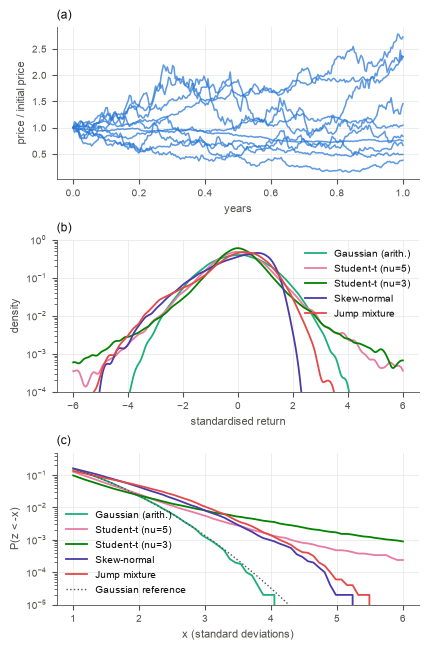

**Fig. 1** Data-generating processes. (a) Ten normalised price paths of one Gaussian GBM universe. (b) Kernel density of standardised daily returns, pooled over 20 universes, for the Gaussian arithmetic diffusion and the four non-Gaussian innovation families (log scale). (c) Left-tail probability P(z < -x) of the same standardised returns; the dotted line is the Gaussian reference

[    10 s]


In [14]:
DGPS = standard_dgps()
shape_df = pd.DataFrame({name: panel_shape_stats(dgp, n_universes=CFG["n_shape"], num_days=252) for name, dgp in DGPS.items()}).T
shape_df.columns = ["skewness", "excess kurtosis", "mean pairwise corr"]
display(save_table(shape_df.round(3), "table_dgp_shapes"))

demo = simulate_gbm(10, 252, seed=42)
fig, ax = plt.subplots(3, 1, figsize=(JW, 7.5))
t = np.arange(demo.prices.shape[1]) / TRADING_DAYS
for i in range(demo.num_stocks):
    ax[0].plot(t, demo.prices[i] / demo.prices[i, 0], color=PAL["blue"], lw=1.1, alpha=0.75)
ax[0].set(title="(a)", xlabel="years", ylabel="price / initial price")

xs = np.linspace(-6, 6, 481)
tail_x = np.linspace(1, 6, 60)
for name in ["Gaussian (arith.)", "Student-t (nu=5)", "Student-t (nu=3)", "Skew-normal", "Jump mixture"]:
    R = np.concatenate([DGPS[name](10, 252, seed=s).returns for s in range(20)], axis=0)
    z = ((R - R.mean(axis=1, keepdims=True)) / R.std(axis=1, keepdims=True)).ravel()
    ax[1].plot(xs, stats.gaussian_kde(z)(xs), color=COLOR_DGP[name], label=name)
    ax[2].plot(tail_x, [(z < -x).mean() for x in tail_x], color=COLOR_DGP[name], label=name)
ax[2].plot(tail_x, stats.norm.cdf(-tail_x), color=PAL["ink2"], lw=1, ls=":", label="Gaussian reference")
ax[1].set(title="(b)", xlabel="standardised return", ylabel="density", yscale="log", ylim=(1e-4, 1))
ax[2].set(title="(c)", xlabel="x (standard deviations)", ylabel="P(z < -x)", yscale="log", ylim=(1e-5, 0.5))
fig.subplots_adjust(hspace=0.4)
ax[1].legend(loc="upper right")
ax[2].legend(loc="lower left")
savefig(fig, "fig01_dgps")
print(elapsed())

## 3. The forward problem and its exact inverse

The investor solves

$$\min_w \; -w^\top \hat r + \eta\, w^\top \Sigma w \quad \text{s.t.} \quad e^\top w = 1,\;\; -c \le w_i \le 1,$$

with sample moments $(\hat r, \Sigma)$, risk aversion $\eta$ and short cap $c$. Stationarity of the
Lagrangian gives, for every asset,

$$\hat r_i = 2\eta(\Sigma w^*)_i + \nu - \mu_i + \lambda_i,$$

where $\nu$ is the budget multiplier and $\mu_i, \lambda_i \ge 0$ are the multipliers of the floor
and the cap. The **KKT inverse** drops the bound multipliers:
$r^{\text{imp}} = 2\eta \Sigma w^* + \nu e$. It equals $\hat r$ for assets strictly inside the bounds,
is an *upper* bound at the floor and a *lower* bound at the cap (the source notebooks labelled
cap-binding assets as slack; audit item I-7). Re-optimising $r^{\text{imp}}$ must return $w^*$
exactly: $w^*$ satisfies the first-order conditions of the new problem with all bound multipliers
equal to zero, and the problem is strictly convex.

Interior-point solvers return weights $10^{-8}$ inside the bounds with $10^{-7}$ stationarity
error; because daily covariance matrices have eigenvalues around $10^{-5}$, that maps to weight
errors around $10^{-3}$ and the exactness claim fails numerically. `solve_mean_variance` therefore
re-solves the equality-constrained QP on the active set identified by the solver (a one-step
active-set polish). The tests assert re-optimisation errors below $10^{-8}$ in every regime.

**Identifiability.** Adding a constant $d$ to every expected return changes the objective by
$d\, e^\top w = d$ for every feasible $w$, so the optimal portfolio does not move: the data identify
the *cross-sectional pattern* of implied returns, never their level. The budget dual absorbs the
level; any $\nu$ is a valid gauge.

,weight,status,sample mean (ann %),implied (ann %),implied - sample (ann %),bound multiplier (ann %)
asset,,,,,,
0,0.0100,SLACK,-20.2638,-20.2638,-0.0000,0.0000
1,-0.5000,BINDING_LOWER,-20.5169,-6.0841,14.4328,14.4328
2,0.0546,SLACK,4.7052,4.7052,0.0000,0.0000
3,1.0000,BINDING_UPPER,36.3321,18.1619,-18.1702,18.1702
4,-0.5000,BINDING_LOWER,-11.0277,-7.7460,3.2816,3.2816
5,-0.1811,SLACK,-36.3723,-36.3723,0.0000,0.0000
6,0.6305,SLACK,153.1142,153.1142,0.0000,0.0000
7,-0.1044,SLACK,-62.6812,-62.6812,0.0000,0.0000
8,0.3719,SLACK,110.9446,110.9446,-0.0000,0.0000


budget dual nu = +2.99 ann %   re-optimisation error = 8.9e-16   worst error over the level-shift family = 5.8e-15


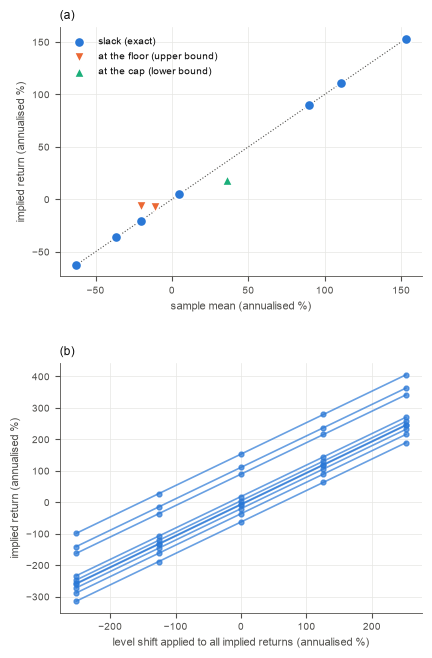

**Fig. 2** Exact KKT inverse and identifiability for one universe (eta = 5, short cap 0.5). (a) Implied return against sample mean per asset: circles are slack assets, downward triangles assets at the floor, upward triangles assets at the cap; the dotted line is the diagonal. (b) Level-shift family of the implied-return vector: each line is one asset, and every member of the family re-optimises to the same weights

In [15]:
panel = simulate_gbm(10, 100, seed=7)
r_hat, Sigma = panel.sample_moments()
sol = solve_mean_variance(r_hat, Sigma, BASE_ETA, BASE_CAP, 1.0)
r_imp, status = invert_solution(Sigma, sol)
anatomy = pd.DataFrame({"weight": sol.weights, "status": status, "sample mean (ann %)": r_hat * ANN_PCT,
                        "implied (ann %)": r_imp * ANN_PCT, "implied - sample (ann %)": (r_imp - r_hat) * ANN_PCT,
                        "bound multiplier (ann %)": (sol.lower_dual + sol.upper_dual) * ANN_PCT})
anatomy.index.name = "asset"
display(save_table(anatomy.round(4), "table_kkt_anatomy"))

w_re = solve_mean_variance(r_imp, Sigma, BASE_ETA, BASE_CAP, 1.0).weights
REOPT_ERR = float(np.abs(w_re - sol.weights).max())
shifts = np.array([-0.010, -0.005, 0.0, 0.005, 0.010])            # daily level shifts, +/- 252 percent annualised
family = level_shift_family(r_imp, shifts)
FAMILY_ERR = max(float(np.abs(solve_mean_variance(row, Sigma, BASE_ETA, BASE_CAP, 1.0).weights - sol.weights).max()) for row in family)
print(f"budget dual nu = {sol.budget_dual * ANN_PCT:+.2f} ann %   re-optimisation error = {REOPT_ERR:.1e}   "
      f"worst error over the level-shift family = {FAMILY_ERR:.1e}")

fig, ax = plt.subplots(2, 1, figsize=(JW, 7.6))
markers = {STATUS_SLACK: "o", STATUS_LOWER: "v", STATUS_UPPER: "^"}
labels = {STATUS_SLACK: "slack (exact)", STATUS_LOWER: "at the floor (upper bound)", STATUS_UPPER: "at the cap (lower bound)"}
for st in [STATUS_SLACK, STATUS_LOWER, STATUS_UPPER]:
    mask = status == st
    if mask.any():
        ax[0].scatter(r_hat[mask] * ANN_PCT, r_imp[mask] * ANN_PCT, marker=markers[st], s=55, color=COLOR_STATUS[st],
                      edgecolor="white", linewidth=1.2, label=labels[st], zorder=3)
lim = np.array([min(r_hat.min(), r_imp.min()), max(r_hat.max(), r_imp.max())]) * ANN_PCT
ax[0].plot(lim, lim, color=PAL["ink2"], lw=0.8, ls=":")
ax[0].set(title="(a)", xlabel="sample mean (annualised %)", ylabel="implied return (annualised %)")
ax[0].legend(loc="upper left")
for i in range(10):
    ax[1].plot(shifts * ANN_PCT, family[:, i] * ANN_PCT, color=PAL["blue"], alpha=0.7, marker="o", ms=3.5, lw=1.2)
ax[1].set(title="(b)", xlabel="level shift applied to all implied returns (annualised %)", ylabel="implied return (annualised %)")
fig.subplots_adjust(hspace=0.35)
savefig(fig, "fig02_kkt_anatomy_identifiability")

## 4. Learning the inverse: how the short cap shapes learnability

A supervised surrogate replaces the closed form. Per asset the features are
$x_i = [w_i,\; \Sigma_{ii},\; (\Sigma w)_i,\; \hat r_i,\; \eta]$; a Huber regressor learns the implied
return (robust to the kink that complementary slackness introduces at the bounds) and a logistic
classifier learns the binding flag (a diagnostic; only the regressor feeds decisions). Training
data are 120 independent universes times three risk aversions. The 1st-step notebook picked the
regime with the highest classification accuracy among three; the 3rd step swept the cap. Both are
reproduced here in one sweep. "none" means no floor; the cap at $+1$ stays, so a few assets can
still bind from above.

cap   0.0: clf acc 0.976   R2 0.543   RMSE 1.63e-03   binding 61.3%   [    18 s]


cap   0.1: clf acc 0.969   R2 0.659   RMSE 1.68e-03   binding 45.0%   [    21 s]


cap  0.25: clf acc 0.961   R2 0.717   RMSE 1.75e-03   binding 33.5%   [    23 s]


cap   0.5: clf acc 0.977   R2 0.814   RMSE 1.50e-03   binding 25.8%   [    25 s]


cap   1.0: clf acc 0.974   R2 0.878   RMSE 1.25e-03   binding 20.7%   [    27 s]


cap  none: clf acc 0.980   R2 0.891   RMSE 1.24e-03   binding 17.2%   [    29 s]


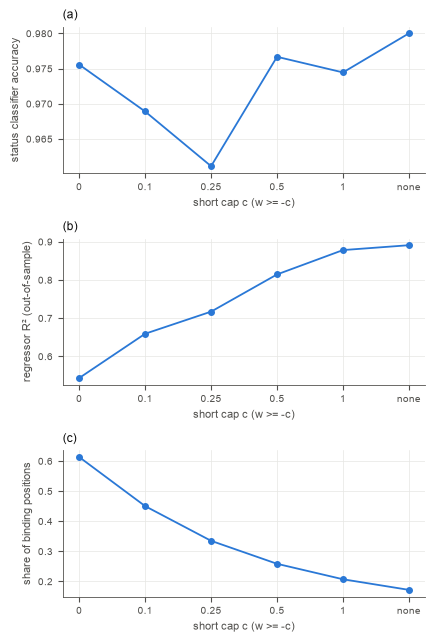

**Fig. 3** Learnability of the inverse as a function of the short cap c (w >= -c); none means no floor while the cap at +1 is kept. (a) Out-of-sample accuracy of the three-class status classifier. (b) Out-of-sample R squared of the Huber regressor. (c) Share of binding positions in the training data

,clf_acc,r2,rmse,trivial,binding_frac,n_train
cap,,,,,,
0,0.9756,0.5432,0.0016,False,0.6131,2700
0.1,0.9689,0.6590,0.0017,False,0.4500,2700
0.25,0.9611,0.7169,0.0018,False,0.3347,2700
0.5,0.9767,0.8142,0.0015,False,0.2583,2700
1,0.9744,0.8779,0.0012,False,0.2069,2700
none,0.9800,0.8906,0.0012,False,0.1717,2700


In [16]:
cap_rows, cap_models = [], {}
for cap in CFG["caps"]:
    X, y, b = build_kkt_dataset(simulate_gbm, CFG["n_train_universes"], CFG["etas_train"], short_limit=cap, max_weight=1.0)
    s = train_surrogate(X, y, b)
    cap_models[cap] = s
    cap_rows.append(dict(cap="none" if cap is None else f"{cap:g}", **s.metrics))
    print(f"cap {'none' if cap is None else cap:>5}: clf acc {s.metrics['clf_acc']:.3f}{' (trivial)' if s.metrics['trivial'] else ''}"
          f"   R2 {s.metrics['r2']:.3f}   RMSE {s.metrics['rmse']:.2e}   binding {s.metrics['binding_frac']*100:4.1f}%   {elapsed()}")
cap_df = pd.DataFrame(cap_rows).set_index("cap")
save_table(cap_df, "table_cap_sweep")
SURROGATE = cap_models[BASE_CAP]

fig, ax = plt.subplots(3, 1, figsize=(JW, 7.4))
xpos = np.arange(len(cap_df))
for a, col, ttl, yl in [(ax[0], "clf_acc", "(a)", "status classifier accuracy"),
                        (ax[1], "r2", "(b)", "regressor R² (out-of-sample)"),
                        (ax[2], "binding_frac", "(c)", "share of binding positions")]:
    vals = cap_df[col].values
    a.plot(xpos, vals, color=PAL["blue"], marker="o", zorder=3)
    triv = cap_df["trivial"].values.astype(bool)
    if triv.any():
        a.scatter(xpos[triv], vals[triv], s=90, facecolor="white", edgecolor=PAL["orange"], linewidth=1.8, zorder=4, label="trivial classifier")
        a.legend(loc="lower right")
    a.set(title=ttl, xlabel="short cap c (w >= -c)", ylabel=yl, xticks=xpos, xticklabels=cap_df.index)
fig.subplots_adjust(hspace=0.45)
savefig(fig, "fig03_learnability_vs_cap")
display(cap_df.round(4))

## 5. Does the learned inverse improve decisions? Out-of-sample evaluation

Protocol (1st-step notebook). Each test universe has 260 days; the first 130 estimate
$(\hat r, \Sigma)$ and the portfolios, the last 130 realise the mean-variance utility
$U = w^\top \bar r_{\text{oos}} - \eta\, w^\top \Sigma_{\text{oos}} w$. Three pipelines:

1. **two-stage**: optimise the noisy sample mean directly;
2. **exact KKT inverse**: invert, then re-optimise. Must reproduce (1) exactly. This is the *null*;
3. **surrogate**: feed the learned inverse's prediction to the optimiser (model trained on seeds
   0-119, tested on seeds 1000 and up: no overlap).

Tests: one-sided paired t-test on per-universe utilities, a risk-aversion sweep with Bonferroni
correction, and a volatility-matched Newey-West test on pooled daily return differences (both
portfolios scaled to 20 percent annual volatility on the estimation window, as in Section 4.4 of
Wang, Gao, Harvey, Liu and Tao (2026)). The surrogate never sees more information than the two-stage
pipeline: any gain is *decision-aware shrinkage* of the sample mean learned from other universes.

surrogate vs two-stage (eta = 5, n = 400): mean gain +2.26e-04 [+1.91e-04, +2.61e-04]   t = 12.67   p(one-sided) = <1e-16   win 80.8%
exact KKT vs two-stage (null):        mean +5.5e-20   t = 0.501   p = 0.308
vol-matched daily difference, Newey-West (52,000 obs, 15 lags): mean +2.39e-05   t = 4.65   p(one-sided) = 1.68e-06
[    40 s]


,mean,ci_lo,ci_hi,t,p_one,p_bonferroni,reject_5pct,win,n
eta,,,,,,,,,
1.0,0.000162,0.000034,0.000291,2.478545,0.007012,0.03506,True,0.635,200
2.0,0.000282,0.000197,0.000367,6.489540,0.000000,0.00000,True,0.750,200
5.0,0.000253,0.000200,0.000306,9.399394,0.000000,0.00000,True,0.805,200
10.0,0.000128,0.000100,0.000156,9.036761,0.000000,0.00000,True,0.810,200
20.0,0.000045,0.000034,0.000055,8.156138,0.000000,0.00000,True,0.725,200


[    56 s]


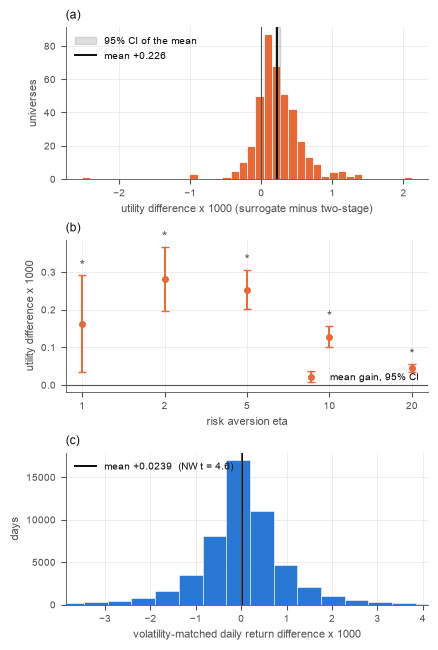

**Fig. 4** Decision value of the learned inverse on Gaussian GBM markets. (a) Per-universe out-of-sample utility gain of the surrogate over the two-stage pipeline at eta = 5, with mean and 95 percent confidence interval. (b) Mean gain and 95 percent confidence interval across risk aversion; stars mark comparisons that stay significant after Bonferroni correction. (c) Pooled volatility-matched daily return differences with the Newey-West t statistic

In [17]:
MAIN = run_oos_battery(simulate_gbm, SURROGATE, eta=BASE_ETA, n_universes=CFG["n_main"], seed0=1000)
print(f"surrogate vs two-stage (eta = {BASE_ETA:g}, n = {MAIN['n']}): mean gain {MAIN['main']['mean']:+.2e} "
      f"[{MAIN['main']['ci_lo']:+.2e}, {MAIN['main']['ci_hi']:+.2e}]   t = {MAIN['main']['t']:.2f}   "
      f"p(one-sided) = {fmt_p(MAIN['main']['p_one'])}   win {MAIN['main']['win']*100:.1f}%")
print(f"exact KKT vs two-stage (null):        mean {MAIN['null']['mean']:+.1e}   t = {MAIN['null']['t']:.3f}   p = {fmt_p(MAIN['null']['p_one'])}")
nw = MAIN["newey_west"]
print(f"vol-matched daily difference, Newey-West ({nw['n']:,} obs, {nw['lags']} lags): mean {nw['mean']:+.2e}   t = {nw['t']:.2f}   p(one-sided) = {fmt_p(nw['p_one'])}")
print(elapsed())

SWEEP = eta_sweep(simulate_gbm, SURROGATE, CFG["eta_sweep"], n_universes=CFG["n_eta"], seed0=2000)
display(save_table(SWEEP.set_index("eta")[["mean", "ci_lo", "ci_hi", "t", "p_one", "p_bonferroni", "reject_5pct", "win", "n"]].round(6), "table_eta_sweep"))
print(elapsed())

fig, ax = plt.subplots(3, 1, figsize=(JW, 7.5))
d = (MAIN["utilities"]["surrogate"] - MAIN["utilities"]["two_stage"]) * 1e3
ax[0].hist(d, bins=40, color=PAL["orange"], edgecolor="white", linewidth=0.6)
ax[0].axvline(0, color=PAL["ink2"], lw=0.8)
ax[0].axvspan(MAIN["main"]["ci_lo"] * 1e3, MAIN["main"]["ci_hi"] * 1e3, color=PAL["ink2"], alpha=0.18, label="95% CI of the mean")
ax[0].axvline(d.mean(), color=PAL["ink"], lw=1.4, label=f"mean {d.mean():+.3f}")
ax[0].set(title="(a)", xlabel="utility difference x 1000 (surrogate minus two-stage)", ylabel="universes")
ax[0].legend(loc="upper left")
xs_ = np.arange(len(SWEEP))
ax[1].errorbar(xs_, SWEEP["mean"] * 1e3, yerr=1.96 * SWEEP["se"] * 1e3, fmt="o", color=PAL["orange"], capsize=3, lw=1.4, label="mean gain, 95% CI")
for k, rej in enumerate(SWEEP["reject_5pct"]):
    ax[1].annotate("*" if rej else "n.s.", (xs_[k], (SWEEP["mean"].iloc[k] + 1.96 * SWEEP["se"].iloc[k]) * 1e3), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9, color=PAL["ink2"])
ax[1].axhline(0, color=PAL["ink2"], lw=0.8)
ax[1].set(title="(b)", xlabel="risk aversion eta", ylabel="utility difference x 1000", xticks=xs_, xticklabels=[f"{e:g}" for e in SWEEP["eta"]])
ax[1].legend(loc="lower right")
D = MAIN["vol_matched_diff"] * 1e3
ax[2].hist(D, bins=60, color=PAL["blue"], edgecolor="white", linewidth=0.4)
ax[2].axvline(D.mean(), color=PAL["ink"], lw=1.4, label=f"mean {D.mean():+.4f}  (NW t = {nw['t']:.1f})")
ax[2].axvline(0, color=PAL["ink2"], lw=0.8)
ax[2].set(title="(c)", xlabel="volatility-matched daily return difference x 1000", ylabel="days", xlim=np.percentile(D, [0.5, 99.5]))
ax[2].legend(loc="upper left")
fig.subplots_adjust(hspace=0.4)
savefig(fig, "fig04_decision_value")

## 6. Robustness: correlation, heavy tails, skewness, and the return representation

The same train-and-test protocol is repeated for every DGP in the menu (surrogate re-trained per
DGP, 300 test universes each). The **log versus arithmetic** question (4th step, section D) fits
weights on the log-return panel of the *same* paths and realises utility on simple returns; the
source notebook re-simulated different paths for the log panel (audit item I-8). A one-sided
paired test asks whether estimating on simple returns beats estimating on log returns for an
arithmetic (wealth) objective. The 6th-step picture, the dispersion of implied returns under a
Gaussian versus a skew-normal market with identical mean and variance, closes the section.

In [18]:
rob_rows, ROB = [], {}
def battery_row(name, res, metrics):
    return dict(dgp=name, clf_acc=metrics["clf_acc"], r2=metrics["r2"], binding=metrics["binding_frac"],
                gain=res["main"]["mean"], ci_lo=res["main"]["ci_lo"], ci_hi=res["main"]["ci_hi"], t=res["main"]["t"],
                p_one=res["main"]["p_one"], win=res["main"]["win"], null_t=res["null"]["t"], null_mean=res["null"]["mean"],
                nw_t=res["newey_west"]["t"], nw_p=res["newey_west"]["p_one"], n=res["n"])
rob_rows.append(battery_row("Gaussian (GBM)", MAIN, SURROGATE.metrics))
for name in [n for n in DGPS if n != "Gaussian (GBM)"]:
    X, y, b = build_kkt_dataset(DGPS[name], CFG["n_train_universes"], CFG["etas_train"], short_limit=BASE_CAP)
    s = train_surrogate(X, y, b)
    res = run_oos_battery(DGPS[name], s, eta=BASE_ETA, n_universes=CFG["n_robust"], seed0=1000)
    ROB[name] = res
    rob_rows.append(battery_row(name, res, s.metrics))
    print(f"{name:18s} clf {s.metrics['clf_acc']:.3f}  R2 {s.metrics['r2']:.3f} | gain {res['main']['mean']:+.2e}  t {res['main']['t']:6.2f}  "
          f"p {fmt_p(res['main']['p_one']):>8}  win {res['main']['win']*100:4.1f}% | null t {res['null']['t']:+.2f} | NW t {res['newey_west']['t']:.2f}  {elapsed()}")
ROBUST = pd.DataFrame(rob_rows).set_index("dgp")
save_table(ROBUST, "table_robustness")

# log versus arithmetic estimation panel on identical paths
def dgp_log(num_stocks=10, num_days=100, seed=0):
    return simulate_gbm(num_stocks, num_days, seed).log_returns()
Xl, yl, bl = build_kkt_dataset(dgp_log, CFG["n_train_universes"], CFG["etas_train"], short_limit=BASE_CAP)
SUR_LOG = train_surrogate(Xl, yl, bl)
U = {k: [] for k in ["two_simple", "two_log", "sur_simple", "sur_log"]}
pattern_corr, pattern_mad = [], []
for i in range(CFG["n_robust"]):
    pnl = simulate_gbm(10, 260, seed=5000 + i)
    fit_s, oos = pnl.window(0, 130), pnl.window(130, 260)
    pw_s = fit_pipelines(fit_s, SURROGATE, BASE_ETA)
    pw_l = fit_pipelines(fit_s.log_returns(), SUR_LOG, BASE_ETA)
    U["two_simple"].append(realised_mv_utility(oos, pw_s.two_stage, BASE_ETA))
    U["two_log"].append(realised_mv_utility(oos, pw_l.two_stage, BASE_ETA))
    U["sur_simple"].append(realised_mv_utility(oos, pw_s.surrogate, BASE_ETA))
    U["sur_log"].append(realised_mv_utility(oos, pw_l.surrogate, BASE_ETA))
    a = pw_s.r_implied - pw_s.r_implied.mean()
    bb = np.expm1(pw_l.r_implied - pw_l.r_implied.mean())
    pattern_corr.append(np.corrcoef(a, bb)[0, 1]); pattern_mad.append(np.abs(a - bb).mean())
LOG_TWO, LOG_SUR = paired_test(U["two_simple"], U["two_log"]), paired_test(U["sur_simple"], U["sur_log"])
LOG_PATTERN = dict(corr=float(np.mean(pattern_corr)), mad_ann_pct=float(np.mean(pattern_mad) * ANN_PCT), clf_acc=SUR_LOG.metrics["clf_acc"], r2=SUR_LOG.metrics["r2"])
print(f"\nlog panel surrogate: clf {LOG_PATTERN['clf_acc']:.3f}  R2 {LOG_PATTERN['r2']:.3f}")
print(f"two-stage, simple minus log estimation: mean {LOG_TWO['mean']:+.2e}  t {LOG_TWO['t']:+.2f}  p {fmt_p(LOG_TWO['p_one'])}  win {LOG_TWO['win']*100:.1f}%")
print(f"surrogate, simple minus log estimation: mean {LOG_SUR['mean']:+.2e}  t {LOG_SUR['t']:+.2f}  p {fmt_p(LOG_SUR['p_one'])}  win {LOG_SUR['win']*100:.1f}%")
print(f"implied-return pattern (de-meaned): mean corr(simple, log) = {LOG_PATTERN['corr']:.4f}, mean abs gap {LOG_PATTERN['mad_ann_pct']:.2f} ann %   {elapsed()}")
pd.DataFrame([dict(comparison="two-stage: simple - log", **LOG_TWO), dict(comparison="surrogate: simple - log", **LOG_SUR)]).set_index("comparison").to_csv(OUT / "table_log_vs_simple.csv")
display(ROBUST[["clf_acc", "r2", "binding", "gain", "t", "p_one", "win", "null_t", "nw_t", "n"]].round(4))

Gaussian (arith.)  clf 0.963  R2 0.855 | gain +2.69e-04  t  13.54  p   <1e-16  win 84.7% | null t +0.60 | NW t 3.88  [    68 s]


One-factor         clf 0.970  R2 0.783 | gain +3.98e-04  t   9.34  p   <1e-16  win 70.0% | null t +1.87 | NW t 3.32  [    75 s]


Student-t (nu=5)   clf 0.967  R2 0.801 | gain +1.70e-04  t  10.56  p   <1e-16  win 74.3% | null t -0.23 | NW t 1.08  [    84 s]


Student-t (nu=3)   clf 0.970  R2 0.840 | gain +2.81e-04  t  11.86  p   <1e-16  win 83.3% | null t -0.55 | NW t 4.08  [    91 s]


Skew-normal        clf 0.969  R2 0.824 | gain +2.57e-04  t  15.31  p   <1e-16  win 85.3% | null t +1.62 | NW t 4.99  [    98 s]


Jump mixture       clf 0.962  R2 0.856 | gain +2.17e-04  t  12.78  p   <1e-16  win 80.3% | null t -0.05 | NW t 4.82  [   105 s]



log panel surrogate: clf 0.973  R2 0.800
two-stage, simple minus log estimation: mean +1.41e-04  t +3.88  p 6.36e-05  win 58.3%
surrogate, simple minus log estimation: mean +9.95e-05  t +3.00  p 0.001  win 54.7%
implied-return pattern (de-meaned): mean corr(simple, log) = 0.9848, mean abs gap 11.17 ann %   [   119 s]


,clf_acc,r2,binding,gain,t,p_one,win,null_t,nw_t,n
dgp,,,,,,,,,,
Gaussian (GBM),0.9767,0.8142,0.2583,0.0002,12.6728,0.0,0.8075,0.5010,4.6471,400
Gaussian (arith.),0.9633,0.8548,0.2619,0.0003,13.5438,0.0,0.8467,0.6006,3.8840,300
One-factor,0.9700,0.7835,0.4003,0.0004,9.3383,0.0,0.7000,1.8664,3.3152,300
Student-t (nu=5),0.9667,0.8013,0.2528,0.0002,10.5561,0.0,0.7433,-0.2252,1.0810,300
Student-t (nu=3),0.9700,0.8398,0.2631,0.0003,11.8639,0.0,0.8333,-0.5530,4.0788,300
Skew-normal,0.9689,0.8237,0.2589,0.0003,15.3072,0.0,0.8533,1.6169,4.9934,300
Jump mixture,0.9622,0.8559,0.2578,0.0002,12.7819,0.0,0.8033,-0.0511,4.8219,300


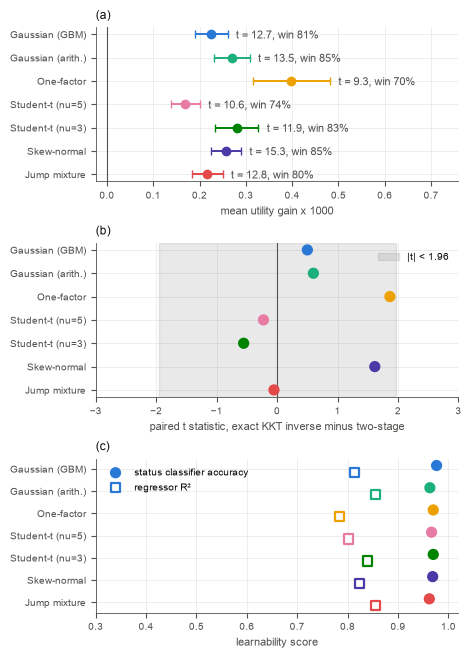

**Fig. 5** Robustness across data-generating processes at eta = 5. (a) Mean utility gain of the surrogate over the two-stage pipeline with 95 percent confidence interval, paired t statistic and win rate. (b) Null check: paired t statistic of the exact KKT inverse against the two-stage pipeline; the band marks |t| < 1.96. (c) Learnability: status classifier accuracy (filled circles) and regressor R squared (open squares)

In [19]:
fig, ax = plt.subplots(3, 1, figsize=(JW, 7.6))
ypos = np.arange(len(ROBUST))[::-1]
for k, (name, row) in enumerate(ROBUST.iterrows()):
    ax[0].errorbar(row["gain"] * 1e3, ypos[k], xerr=[[(row["gain"] - row["ci_lo"]) * 1e3], [(row["ci_hi"] - row["gain"]) * 1e3]],
                   fmt="o", color=COLOR_DGP[name], capsize=3, lw=1.4, ms=6)
    ax[0].annotate(f"t = {row['t']:.1f}, win {row['win']*100:.0f}%", (row["ci_hi"] * 1e3, ypos[k]), textcoords="offset points", xytext=(6, -3), fontsize=8, color=PAL["ink2"])
ax[0].axvline(0, color=PAL["ink2"], lw=0.8)
ax[0].set(title="(a)", xlabel="mean utility gain x 1000", yticks=ypos, yticklabels=ROBUST.index)
ax[0].set_xlim(left=min(0, ax[0].get_xlim()[0]), right=ax[0].get_xlim()[1] * 1.5)
ax[1].scatter(ROBUST["null_t"], ypos, color=[COLOR_DGP[n] for n in ROBUST.index], s=50, zorder=3)
ax[1].axvspan(-1.96, 1.96, color=PAL["ink2"], alpha=0.12, label="|t| < 1.96")
ax[1].axvline(0, color=PAL["ink2"], lw=0.8)
ax[1].set(title="(b)", xlabel="paired t statistic, exact KKT inverse minus two-stage", yticks=ypos, yticklabels=ROBUST.index, xlim=(-3, 3))
ax[1].legend(loc="upper right")
ax[2].scatter(ROBUST["clf_acc"], ypos + 0.15, color=[COLOR_DGP[n] for n in ROBUST.index], marker="o", s=50, zorder=3, label="status classifier accuracy")
ax[2].scatter(ROBUST["r2"], ypos - 0.15, color=[COLOR_DGP[n] for n in ROBUST.index], marker="s", s=45, zorder=3, facecolors="white", linewidths=1.6, label="regressor R²")
ax[2].set(title="(c)", xlabel="learnability score", yticks=ypos, yticklabels=ROBUST.index, xlim=(0.3, 1.02))
ax[2].legend(loc="upper left")
fig.subplots_adjust(hspace=0.4)
savefig(fig, "fig05_robustness_forest")

,mean_std_ann_pct,median_std_ann_pct,pooled_skew,pooled_excess_kurt
Gaussian (arith.),59.028,57.993,-0.037,1.417
Skew-normal,60.564,60.035,-0.005,1.438


Kolmogorov-Smirnov test on per-universe implied-return std, Gaussian vs skew-normal: D = 0.062, p = 0.292


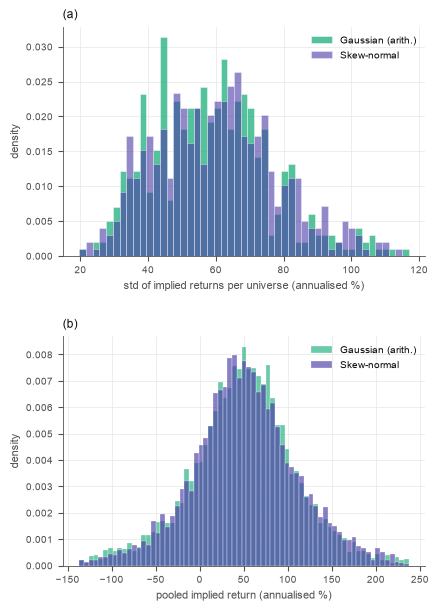

**Fig. 6** Implied-return dispersion under Gaussian and skew-normal innovations with identical means and variances (eta = 5, 500 universes each). (a) Cross-sectional standard deviation of implied returns per universe. (b) Pooled implied returns

[   133 s]


In [20]:
DISP = {}
for name in ["Gaussian (arith.)", "Skew-normal"]:
    imps = []
    for seed in range(CFG["n_dispersion"]):
        r_, S_ = DGPS[name](10, 252, seed=seed).sample_moments()
        imps.append(invert_solution(S_, solve_mean_variance(r_, S_, BASE_ETA, BASE_CAP, 1.0))[0])
    DISP[name] = np.vstack(imps)
std_g, std_s = DISP["Gaussian (arith.)"].std(axis=1) * ANN_PCT, DISP["Skew-normal"].std(axis=1) * ANN_PCT
KS_DISP = stats.ks_2samp(std_g, std_s)
DISP_STATS = pd.DataFrame({name: dict(mean_std_ann_pct=DISP[name].std(axis=1).mean() * ANN_PCT, median_std_ann_pct=np.median(DISP[name].std(axis=1)) * ANN_PCT,
                                     pooled_skew=stats.skew(DISP[name].ravel()), pooled_excess_kurt=stats.kurtosis(DISP[name].ravel()))
                           for name in DISP}).T
display(save_table(DISP_STATS.round(3), "table_dispersion"))
print(f"Kolmogorov-Smirnov test on per-universe implied-return std, Gaussian vs skew-normal: D = {KS_DISP.statistic:.3f}, p = {fmt_p(KS_DISP.pvalue)}")

fig, ax = plt.subplots(2, 1, figsize=(JW, 7.0))
bins = np.linspace(min(std_g.min(), std_s.min()), np.percentile(np.r_[std_g, std_s], 99.5), 50)
ax[0].hist(std_g, bins=bins, density=True, color=COLOR_DGP["Gaussian (arith.)"], alpha=0.75, edgecolor="white", linewidth=0.4, label="Gaussian (arith.)")
ax[0].hist(std_s, bins=bins, density=True, color=COLOR_DGP["Skew-normal"], alpha=0.6, edgecolor="white", linewidth=0.4, label="Skew-normal")
ax[0].set(title="(a)", xlabel="std of implied returns per universe (annualised %)", ylabel="density")
ax[0].legend(loc="upper right")
lo, hi = np.percentile(np.r_[DISP["Gaussian (arith.)"].ravel(), DISP["Skew-normal"].ravel()] * ANN_PCT, [0.5, 99.5])
bins2 = np.linspace(lo, hi, 70)
for name in DISP:
    ax[1].hist(DISP[name].ravel() * ANN_PCT, bins=bins2, density=True, color=COLOR_DGP[name], alpha=0.65, edgecolor="white", linewidth=0.3, label=name)
ax[1].set(title="(b)", xlabel="pooled implied return (annualised %)", ylabel="density")
ax[1].legend(loc="upper right")
fig.subplots_adjust(hspace=0.35)
savefig(fig, "fig06_dispersion_gaussian_vs_skew")
print(elapsed())

## 7. Utility mismatch: what returns would a mean-variance investor need to hold the CRRA portfolio?

On identical markets two investors optimise: mean-variance with $\eta$, and CRRA with
$\max_w \frac{1}{T}\sum_t \frac{(1 + w^\top r_t)^{1-\gamma}}{1-\gamma}$ (log utility for $\gamma = 1$).
Both portfolios are pushed through the *same* inverse $r = 2\eta\Sigma w + \nu$ with the
mean-variance budget dual, so the difference of the two implied vectors is gauge-free (audit
item I-15). A second-order expansion gives $E[u(1+R)] \approx E[R] - \frac{\gamma}{2}\mathrm{Var}(R)$,
so CRRA is locally mean-variance when $\gamma = 2\eta$: distributions should coincide on that
diagonal and separate off it. The 2nd-step notebook conjectured that the divergence is carried by
**corner solutions** (positions pinned by a bound rather than by belief); the corner fraction uses
one definition (floor *or* cap) for both investors (audit item I-6). The 5th step asked whether the
picture survives heavy tails and skew; the sweep is repeated for four non-Gaussian DGPs.

[   154 s]


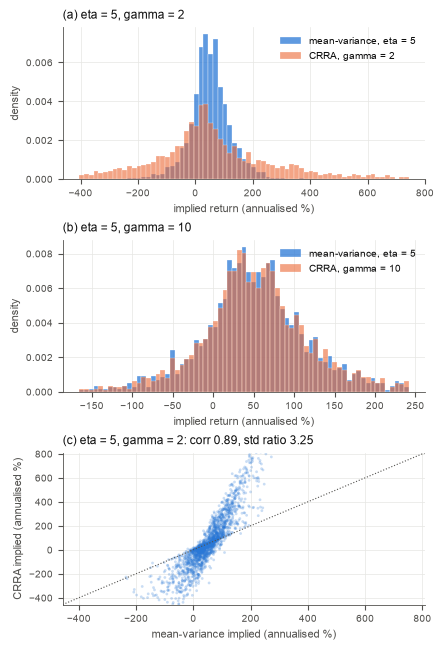

**Fig. 7** Mean-variance and CRRA implied returns on identical Gaussian GBM markets. (a) Distributions at eta = 5 and gamma = 2 (off the diagonal). (b) Distributions at eta = 5 and gamma = 10 (on the diagonal gamma = 2 eta). (c) Asset-by-asset scatter at eta = 5 and gamma = 2; the dotted line is the diagonal

In [21]:
CRRA_G, CRRA_SAMPLES = mv_vs_crra_sweep(simulate_gbm, CFG["crra_etas"], CFG["crra_gammas"], CFG["n_crra_gauss"], num_days=252, keep_samples=True)
save_table(CRRA_G, "table_crra_gaussian")
print(elapsed())
pair = (5.0, 2.0) if (5.0, 2.0) in CRRA_SAMPLES else list(CRRA_SAMPLES)[0]
diag_pair = (5.0, 10.0) if (5.0, 10.0) in CRRA_SAMPLES else next(k for k in CRRA_SAMPLES if np.isclose(k[1], 2 * k[0]))
pm, pc = CRRA_SAMPLES[pair]
dm, dc = CRRA_SAMPLES[diag_pair]

fig, ax = plt.subplots(3, 1, figsize=(JW, 7.5))
lo, hi = np.percentile(np.r_[pm, pc] * ANN_PCT, [0.5, 99.5])
bins = np.linspace(lo, hi, 70)
ax[0].hist(pm * ANN_PCT, bins=bins, density=True, color=PAL["blue"], alpha=0.75, edgecolor="white", linewidth=0.3, label=f"mean-variance, eta = {pair[0]:g}")
ax[0].hist(pc * ANN_PCT, bins=bins, density=True, color=PAL["orange"], alpha=0.6, edgecolor="white", linewidth=0.3, label=f"CRRA, gamma = {pair[1]:g}")
ax[0].set(title=f"(a) eta = {pair[0]:g}, gamma = {pair[1]:g}", xlabel="implied return (annualised %)", ylabel="density")
ax[0].legend(loc="upper right")
lo2, hi2 = np.percentile(np.r_[dm, dc] * ANN_PCT, [0.5, 99.5])
bins2 = np.linspace(lo2, hi2, 70)
ax[1].hist(dm * ANN_PCT, bins=bins2, density=True, color=PAL["blue"], alpha=0.75, edgecolor="white", linewidth=0.3, label=f"mean-variance, eta = {diag_pair[0]:g}")
ax[1].hist(dc * ANN_PCT, bins=bins2, density=True, color=PAL["orange"], alpha=0.6, edgecolor="white", linewidth=0.3, label=f"CRRA, gamma = {diag_pair[1]:g}")
ax[1].set(title=f"(b) eta = {diag_pair[0]:g}, gamma = {diag_pair[1]:g}", xlabel="implied return (annualised %)", ylabel="density")
ax[1].legend(loc="upper right")
idx = np.random.default_rng(0).choice(len(pm), min(4000, len(pm)), replace=False)
ax[2].scatter(pm[idx] * ANN_PCT, pc[idx] * ANN_PCT, s=4, alpha=0.25, color=PAL["blue"], edgecolor="none")
lim = np.percentile(np.r_[pm, pc] * ANN_PCT, [0.2, 99.8])
ax[2].plot(lim, lim, color=PAL["ink2"], lw=0.8, ls=":")
row = CRRA_G[(CRRA_G["eta"] == pair[0]) & (CRRA_G["gamma"] == pair[1])].iloc[0]
ax[2].set(title=f"(c) eta = {pair[0]:g}, gamma = {pair[1]:g}: corr {row['corr']:.2f}, std ratio {row['std_ratio']:.2f}",
          xlabel="mean-variance implied (annualised %)", ylabel="CRRA implied (annualised %)", xlim=lim, ylim=lim)
fig.subplots_adjust(hspace=0.4)
savefig(fig, "fig07_mv_vs_crra_distributions")

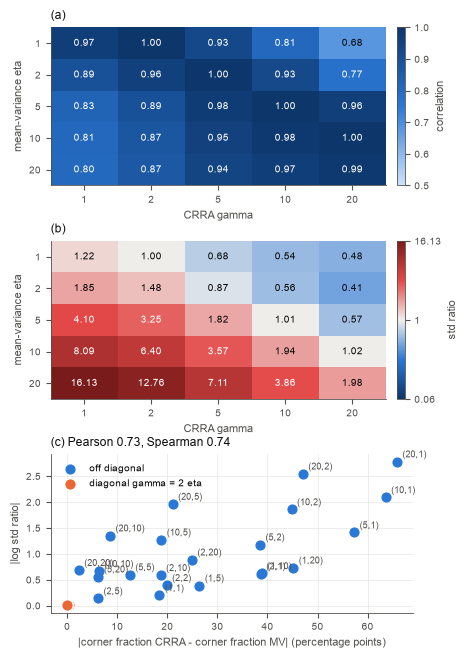

**Fig. 8** Utility mismatch over the (eta, gamma) grid, Gaussian GBM. (a) Correlation between mean-variance and CRRA implied returns. (b) Ratio of the CRRA to the mean-variance standard deviation on a log colour scale (red wider, blue tighter). (c) Absolute log standard-deviation ratio against the corner-fraction mismatch between the two investors; labels give (eta, gamma) and orange points are diagonal pairs

corner mismatch vs |log std ratio|: Pearson 0.727 (p = 3.81e-05), Spearman 0.737; raw CRRA corner share vs |log ratio|: Pearson 0.416


In [22]:
def grid(df, col, etas, gammas):
    M = np.full((len(etas), len(gammas)), np.nan)
    for _, r in df.iterrows():
        M[etas.index(r["eta"]), gammas.index(r["gamma"])] = r[col]
    return M

etas_, gammas_ = CFG["crra_etas"], CFG["crra_gammas"]
CORR_M, RATIO_M = grid(CRRA_G, "corr", etas_, gammas_), grid(CRRA_G, "std_ratio", etas_, gammas_)
fig, ax = plt.subplots(3, 1, figsize=(JW, 7.6))
norm_c = mpl.colors.Normalize(vmin=0.5, vmax=1.0)
im0 = ax[0].imshow(CORR_M, cmap=SEQ_CMAP, norm=norm_c, aspect="auto")
annotate_heatmap(ax[0], CORR_M, cmap=SEQ_CMAP, norm=norm_c)
ax[0].set(title="(a)", xlabel="CRRA gamma", ylabel="mean-variance eta",
          xticks=range(len(gammas_)), xticklabels=[f"{g:g}" for g in gammas_], yticks=range(len(etas_)), yticklabels=[f"{e:g}" for e in etas_])
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.03, label="correlation")
L = np.log2(RATIO_M)
vmax = np.nanmax(np.abs(L))
norm_d = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im1 = ax[1].imshow(L, cmap=DIV_CMAP, norm=norm_d, aspect="auto")
annotate_heatmap(ax[1], RATIO_M, cmap=DIV_CMAP, norm=lambda v: norm_d(np.log2(v)))
ax[1].set(title="(b)", xlabel="CRRA gamma", ylabel="mean-variance eta",
          xticks=range(len(gammas_)), xticklabels=[f"{g:g}" for g in gammas_], yticks=range(len(etas_)), yticklabels=[f"{e:g}" for e in etas_])
cb = fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.03, label="std ratio")
cb.set_ticks([-vmax, 0, vmax]); cb.set_ticklabels([f"{2**-vmax:.2f}", "1", f"{2**vmax:.2f}"])
for a in ax[:2]:
    a.grid(False)
BRIDGE = corner_bridge(CRRA_G)
on = CRRA_G["on_diagonal"].values
ax[2].scatter(BRIDGE["mismatch_pp"][~on], BRIDGE["abs_log_ratio"][~on], color=PAL["blue"], s=40, label="off diagonal", zorder=3)
ax[2].scatter(BRIDGE["mismatch_pp"][on], BRIDGE["abs_log_ratio"][on], color=PAL["orange"], s=70, label="diagonal gamma = 2 eta", zorder=4, edgecolor="white", linewidth=1)
for k, r in CRRA_G.iterrows():
    if not r["on_diagonal"]:
        ax[2].annotate(f"({r['eta']:g},{r['gamma']:g})", (BRIDGE["mismatch_pp"][k], BRIDGE["abs_log_ratio"][k]), textcoords="offset points", xytext=(4, 3), fontsize=6.5, color=PAL["ink2"])
ax[2].set(title=f"(c) Pearson {BRIDGE['pearson_mismatch_logratio']:.2f}, Spearman {BRIDGE['spearman_mismatch_logratio']:.2f}",
          xlabel="|corner fraction CRRA - corner fraction MV| (percentage points)", ylabel="|log std ratio|")
ax[2].legend(loc="upper left")
fig.subplots_adjust(hspace=0.35)
savefig(fig, "fig08_crra_heatmaps_bridge")
print(f"corner mismatch vs |log std ratio|: Pearson {BRIDGE['pearson_mismatch_logratio']:.3f} (p = {fmt_p(BRIDGE['p_pearson'])}), "
      f"Spearman {BRIDGE['spearman_mismatch_logratio']:.3f}; raw CRRA corner share vs |log ratio|: Pearson {BRIDGE['pearson_rawcorner_logratio']:.3f}")

Student-t (nu=5)   done [   183 s]


Student-t (nu=3)   done [   204 s]


Skew-normal        done [   224 s]


Jump mixture       done [   244 s]


,diag_corr_mean,diag_std_ratio_mean,offdiag_corr_min,offdiag_corr_mean,corner_gap_bold_pp,skew_gap_mean,std_ratio_max,std_ratio_min
Gaussian (GBM),0.999,1.011,0.678,0.899,30.900,0.253,16.129,0.412
Student-t (nu=5),0.998,1.021,0.616,0.910,30.209,0.200,17.777,0.308
Student-t (nu=3),0.982,1.092,0.644,0.898,31.196,0.446,17.905,0.331
Skew-normal,0.998,0.990,0.617,0.910,31.364,-0.013,17.065,0.295
Jump mixture,0.998,0.997,0.601,0.903,30.804,0.013,17.396,0.317


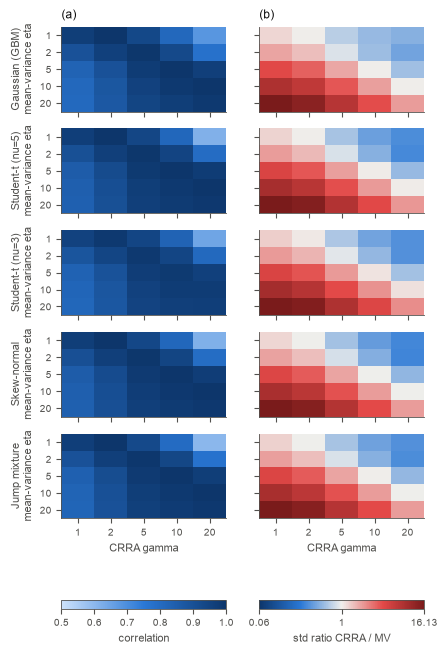

**Fig. 9** The (eta, gamma) sweep under five data-generating processes, one row per process. (a) Correlation between mean-variance and CRRA implied returns. (b) Standard-deviation ratio on a log colour scale

[   249 s]


In [23]:
CRRA_DGP_NAMES = ["Gaussian (GBM)", "Student-t (nu=5)", "Student-t (nu=3)", "Skew-normal", "Jump mixture"]
CRRA_ALL = {"Gaussian (GBM)": CRRA_G}
for name in CRRA_DGP_NAMES[1:]:
    CRRA_ALL[name], _ = mv_vs_crra_sweep(DGPS[name], etas_, gammas_, CFG["n_crra_dgp"], num_days=252)
    print(f"{name:18s} done {elapsed()}")
crra_long = pd.concat([df.assign(dgp=name) for name, df in CRRA_ALL.items()])
save_table(crra_long.set_index(["dgp", "eta", "gamma"]), "table_crra_all_dgps")

def crra_summary(df):
    on, off = df[df["on_diagonal"]], df[~df["on_diagonal"]]
    bold = df[df["gamma"] < 2 * df["eta"]]
    return dict(diag_corr_mean=on["corr"].mean(), diag_std_ratio_mean=on["std_ratio"].mean(), offdiag_corr_min=off["corr"].min(),
                offdiag_corr_mean=off["corr"].mean(), corner_gap_bold_pp=(bold["corner_cr"] - bold["corner_mv"]).mean() * 100,
                skew_gap_mean=(df["skew_cr"] - df["skew_mv"]).mean(), std_ratio_max=df["std_ratio"].max(), std_ratio_min=df["std_ratio"].min())
CRRA_SUM = pd.DataFrame({name: crra_summary(df) for name, df in CRRA_ALL.items()}).T
display(save_table(CRRA_SUM.round(3), "table_crra_summary_by_dgp"))

fig, axes = plt.subplots(len(CRRA_ALL), 2, figsize=(JW, 7.6), sharex=True, sharey=True)
for i, (name, df) in enumerate(CRRA_ALL.items()):
    C, Rt = grid(df, "corr", etas_, gammas_), grid(df, "std_ratio", etas_, gammas_)
    im_c = axes[i, 0].imshow(C, cmap=SEQ_CMAP, norm=norm_c, aspect="auto")
    im_r = axes[i, 1].imshow(np.log2(Rt), cmap=DIV_CMAP, norm=norm_d, aspect="auto")
    axes[i, 0].set_ylabel(f"{name}\nmean-variance eta")
    for a in axes[i]:
        a.grid(False)
        a.set(yticks=range(len(etas_)), yticklabels=[f"{e:g}" for e in etas_])
axes[0, 0].set_title("(a)")
axes[0, 1].set_title("(b)")
for a in axes[-1]:
    a.set(xlabel="CRRA gamma", xticks=range(len(gammas_)), xticklabels=[f"{g:g}" for g in gammas_])
cb1 = fig.colorbar(im_c, ax=axes[:, 0].tolist(), orientation="horizontal", fraction=0.02, pad=0.14, label="correlation")
cb2 = fig.colorbar(im_r, ax=axes[:, 1].tolist(), orientation="horizontal", fraction=0.02, pad=0.14, label="std ratio CRRA / MV")
cb2.set_ticks([-vmax, 0, vmax]); cb2.set_ticklabels([f"{2**-vmax:.2f}", "1", f"{2**vmax:.2f}"])
savefig(fig, "fig09_crra_across_dgps")
print(elapsed())

# Part II. Recovering a Merton risk premium with tree ensembles under different loss functions

## 8. Design

A single asset earns the premium $\pi_t = \gamma\sigma_t^2$ (Merton, $\gamma = 2$) above a 3 percent
risk-free rate, with return $r_t = (r_f + \pi_t)\,dt + \sigma_t\sqrt{dt}\,\varepsilon_t$. The task is a
**nowcast**: recover $\pi_t$ from features built on returns up to and including $t$ (the convention
of the 7th and 8th steps). Four volatility processes:

* **i.i.d. sigma** (uniform on 15 to 25 percent, redrawn every day) with Gaussian, Student-t or
  skew-normal innovations. The premium is unpredictable by construction; this is the negative
  control (7th step, audit item P-9).
* **GARCH(1,1)** ($\omega = 10^{-6}$, $\alpha = 0.09$, $\beta = 0.90$): persistent, learnable.
* **Log-volatility Ornstein-Uhlenbeck** $d\log\sigma = -\kappa \log(\sigma/\bar\sigma)\,dt + \xi\,dW$
  with the stationary spread of log-volatility fixed at 0.35 so that $\kappa$ moves persistence only
  (half-life $\ln 2 / \kappa$). Volatility is positive by construction, which repairs the clipping
  degeneracy of the 8th step (audit item P-3). Returns are aggregated to 21-day months; the realized
  volatility inside each month is an observable feature.

Models: random forests with squared error, absolute error and a scale-free two-pass Huber
reweighting; quantile gradient boosting at $\tau = 0.1, 0.5, 0.9$; a **Merton-structural** two-stage
forest whose first stage learns $\gamma\,\hat\sigma^2$ from *observable* rolling volatility (the
source notebooks handed it the true $\sigma_t$, audit item P-1); and the **SDF-weighted** forest of
the 8th step (heuristic Euler-residual reweighting). Two closed-form references: Merton on rolling
volatility (feasible) and Merton on the true $\sigma_t$ (oracle, equal to the target by construction).
Mean models are scored by bias, RMSE, MAE and $R^2$ (pooled over repetitions and median per
repetition, audit item P-5); quantile models by pinball loss and empirical coverage.

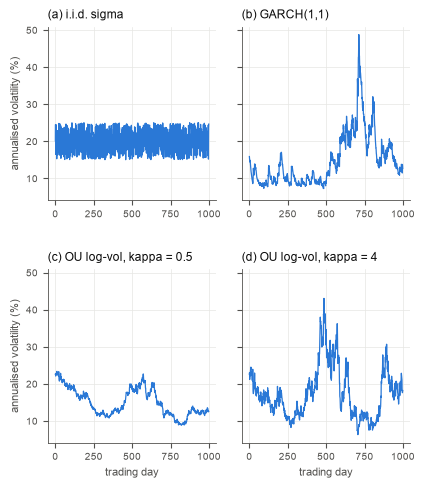

**Fig. 10** Annualised volatility paths of the premium data-generating processes over 1000 trading days. (a) Independent daily volatility. (b) GARCH(1,1). (c) Log-volatility Ornstein-Uhlenbeck with kappa = 0.5 (half-life 17 months). (d) Log-volatility Ornstein-Uhlenbeck with kappa = 4 (half-life 2 months)

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(JW, 5.4), sharey=True)
ax = ax.ravel()
series_demo = [("(a) i.i.d. sigma", premium_iid_sigma(T=1000, seed=1)), ("(b) GARCH(1,1)", premium_garch(T=1000, seed=1)),
               ("(c) OU log-vol, kappa = 0.5", premium_ou_logvol(T=1000, seed=1, kappa=0.5)),
               ("(d) OU log-vol, kappa = 4", premium_ou_logvol(T=1000, seed=1, kappa=4.0))]
for a, (name, s) in zip(ax, series_demo):
    a.plot(s.sigma * 100, color=PAL["blue"], lw=0.9)
    a.set(title=name)
for a in ax[2:]:
    a.set_xlabel("trading day")
for a in ax[::2]:
    a.set_ylabel("annualised volatility (%)")
fig.subplots_adjust(hspace=0.4, wspace=0.15)
savefig(fig, "fig10_premium_dgps")

## 9. Daily frequency: five DGPs, seven mean models, three quantile models

In [26]:
DAILY_GENS = {
    "i.i.d. sigma, Gaussian": lambda T, seed: premium_iid_sigma(T, seed, "gaussian"),
    "i.i.d. sigma, Student-t (nu=5)": lambda T, seed: premium_iid_sigma(T, seed, "student_t", nu=5),
    "i.i.d. sigma, Student-t (nu=3)": lambda T, seed: premium_iid_sigma(T, seed, "student_t", nu=3),
    "i.i.d. sigma, skew-normal": lambda T, seed: premium_iid_sigma(T, seed, "skew_normal"),
    "GARCH(1,1)": lambda T, seed: premium_garch(T, seed),
}
COLOR_PDGP = dict(zip(DAILY_GENS, [PAL["blue"], PAL["magenta"], PAL["green"], PAL["violet"], PAL["orange"]]))
DAILY = {}
for name, gen in DAILY_GENS.items():
    DAILY[name] = run_premium_experiment(gen, n_reps=CFG["n_reps_daily"], T=CFG["T_daily"], params=RFP)
    print(f"{name:32s} SNR {DAILY[name]['signal_to_noise']:.3f}   R2 pooled: " +
          "  ".join(f"{k} {DAILY[name]['summary'].loc[k, 'r2_pooled']:+.3f}" for k in ["MSE", "MAE", "Huber", "Merton-structural", "SDF-weighted"]) + f"   {elapsed()}")
daily_tbl = pd.concat([d["summary"].assign(dgp=name) for name, d in DAILY.items()]).reset_index().set_index(["dgp", "model"])
save_table(daily_tbl, "table_premium_daily")
daily_q = pd.concat([d["quantile_summary"].assign(dgp=name) for name, d in DAILY.items()]).reset_index().set_index(["dgp", "model"])
save_table(daily_q, "table_premium_daily_quantiles")
display(daily_tbl[["r2_pooled", "r2_median", "rmse_mean", "mae_mean", "bias_mean"]].round(4))
display(daily_q.round(4))

i.i.d. sigma, Gaussian           SNR 1.788   R2 pooled: MSE -0.003  MAE -0.013  Huber -0.006  Merton-structural -0.003  SDF-weighted -0.022   [   475 s]


i.i.d. sigma, Student-t (nu=5)   SNR 1.834   R2 pooled: MSE -0.006  MAE -0.016  Huber -0.008  Merton-structural -0.005  SDF-weighted -0.026   [   681 s]


i.i.d. sigma, Student-t (nu=3)   SNR 1.788   R2 pooled: MSE -0.006  MAE -0.016  Huber -0.009  Merton-structural -0.006  SDF-weighted -0.031   [   884 s]


i.i.d. sigma, skew-normal        SNR 1.813   R2 pooled: MSE -0.003  MAE -0.012  Huber -0.006  Merton-structural -0.003  SDF-weighted -0.020   [  1099 s]


GARCH(1,1)                       SNR 3.474   R2 pooled: MSE +0.737  MAE +0.722  Huber +0.676  Merton-structural +0.740  SDF-weighted +0.741   [  1307 s]


r2_pooled  r2_median  \
dgp                            model                                         
i.i.d. sigma, Gaussian         MSE                      -0.0033    -0.0042   
                               MAE                      -0.0130    -0.0131   
                               Huber                    -0.0059    -0.0070   
                               Merton-structural        -0.0034    -0.0051   
                               SDF-weighted             -0.0225    -0.0161   
                               Merton (rolling vol)     -1.3138    -1.2698   
                               Merton (oracle sigma)     1.0000     1.0000   
i.i.d. sigma, Student-t (nu=5) MSE                      -0.0057    -0.0076   
                               MAE                      -0.0164    -0.0175   
                               Huber                    -0.0084    -0.0106   
                               Merton-structural        -0.0055    -0.0068   
                               SDF-weighted             -0.0259    -0.0256   
                               Merton (rolling vol)     -5.0838    -4.0398   
                               Merton (oracle sigma)     1.0000     1.0000   
i.i.d. sigma, Student-t (nu=3) MSE                      -0.0060    -0.0064   
                               MAE                      -0.0161    -0.0162   
                               Huber                    -0.0089    -0.0089   
                               Merton-structural        -0.0058    -0.0066   
                               SDF-weighted             -0.0306    -0.0273   
                               Merton (rolling vol)    -24.4081    -7.4790   
                               Merton (oracle sigma)     1.0000     1.0000   
i.i.d. sigma, skew-normal      MSE                      -0.0031    -0.0019   
                               MAE                      -0.0123    -0.0129   
                               Huber                    -0.0059    -0.0059   
                               Merton-structural        -0.0034    -0.0036   
                               SDF-weighted             -0.0198    -0.0187   
                               Merton (rolling vol)     -1.6711    -1.6589   
                               Merton (oracle sigma)     1.0000     1.0000   
GARCH(1,1)                     MSE                       0.7372     0.9090   
                               MAE                       0.7217     0.9091   
                               Huber                     0.6757     0.8986   
                               Merton-structural         0.7404     0.9090   
                               SDF-weighted              0.7414     0.9065   
                               Merton (rolling vol)      0.9138     0.8861   
                               Merton (oracle sigma)     1.0000     1.0000   

                                                      rmse_mean  mae_mean  \
dgp                            model                                        
i.i.d. sigma, Gaussian         MSE                       0.0231    0.0200   
                               MAE                       0.0232    0.0200   
                               Huber                     0.0231    0.0200   
                               Merton-structural         0.0231    0.0200   
                               SDF-weighted              0.0233    0.0202   
                               Merton (rolling vol)      0.0351    0.0280   
                               Merton (oracle sigma)     0.0000    0.0000   
i.i.d. sigma, Student-t (nu=5) MSE                       0.0231    0.0200   
                               MAE                       0.0233    0.0200   
                               Huber                     0.0232    0.0200   
                               Merton-structural         0.0231    0.0200   
                               SDF-weighted              0.0234    0.0202   
                               Merton (rolling vol)      0.0552    0.0375   
            

pinball  coverage  target
dgp                            model                           
i.i.d. sigma, Gaussian         Q10     0.0035    0.1284     0.1
                               Q50     0.0102    0.4949     0.5
                               Q90     0.0039    0.8718     0.9
i.i.d. sigma, Student-t (nu=5) Q10     0.0035    0.1268     0.1
                               Q50     0.0102    0.4968     0.5
                               Q90     0.0039    0.8693     0.9
i.i.d. sigma, Student-t (nu=3) Q10     0.0035    0.1273     0.1
                               Q50     0.0102    0.4995     0.5
                               Q90     0.0040    0.8685     0.9
i.i.d. sigma, skew-normal      Q10     0.0035    0.1286     0.1
                               Q50     0.0101    0.4934     0.5
                               Q90     0.0040    0.8703     0.9
GARCH(1,1)                     Q10     0.0012    0.1494     0.1
                               Q50     0.0031    0.5009     0.5
                               Q90     0.0024    0.8405     0.9

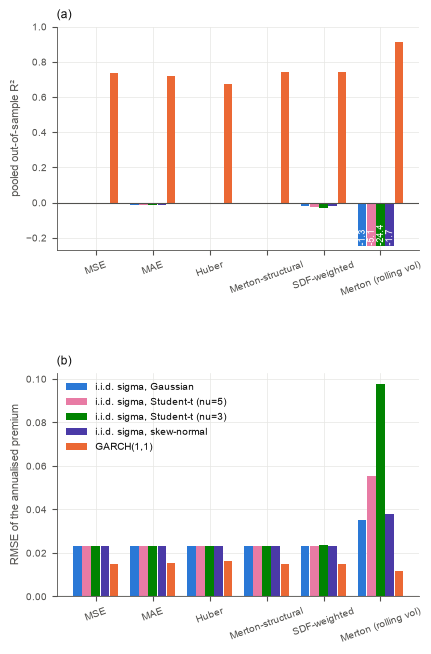

**Fig. 11** Premium recovery at daily frequency. (a) Pooled out-of-sample R squared by model and data-generating process; bars below -0.25 are clipped and labelled with their value. (b) Root mean squared error of the annualised premium

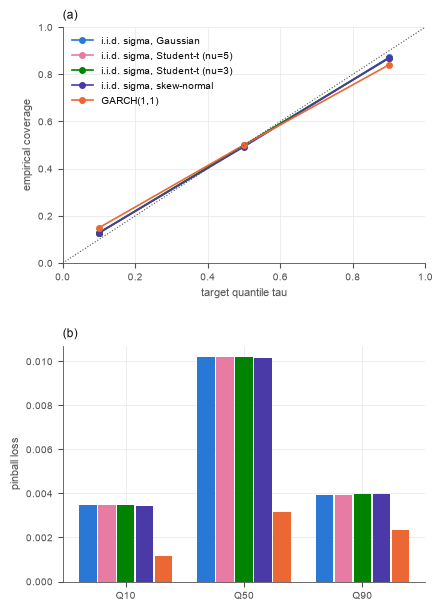

**Fig. 12** Quantile models at daily frequency. (a) Empirical coverage against the target quantile; the dotted line is perfect calibration. (b) Pinball loss by quantile

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(JW, 7.4))
models = MEAN_MODELS[:6]                     # the oracle is 1 by construction and is reported in the table only
xm = np.arange(len(models)); wdt = 0.8 / len(DAILY)
for i, (name, d) in enumerate(DAILY.items()):
    r2 = d["summary"].loc[models, "r2_pooled"].values
    rm = d["summary"].loc[models, "rmse_mean"].values
    clipped = r2 < -0.25
    ax[0].bar(xm + i * wdt, np.maximum(r2, -0.25), wdt * 0.92, color=COLOR_PDGP[name], label=name)
    for j in np.where(clipped)[0]:
        ax[0].text(xm[j] + i * wdt, -0.245, f"{r2[j]:.1f}", ha="center", va="bottom", fontsize=6.5, rotation=90, color="white")
    ax[1].bar(xm + i * wdt, rm, wdt * 0.92, color=COLOR_PDGP[name], label=name)
for a, ttl, yl in [(ax[0], "(a)", "pooled out-of-sample R²"), (ax[1], "(b)", "RMSE of the annualised premium")]:
    a.set(title=ttl, ylabel=yl, xticks=xm + wdt * (len(DAILY) - 1) / 2, xticklabels=models)
    a.axhline(0, color=PAL["ink2"], lw=0.8)
    a.tick_params(axis="x", labelrotation=20)
ax[0].set_ylim(-0.27, 1.0)
ax[1].legend(loc="upper left", ncol=1)
fig.subplots_adjust(hspace=0.55)
savefig(fig, "fig11_premium_daily_r2_rmse")

fig, ax = plt.subplots(2, 1, figsize=(JW, 7.2))
for i, (name, d) in enumerate(DAILY.items()):
    q = d["quantile_summary"]
    ax[0].plot(q["target"], q["coverage"], marker="o", color=COLOR_PDGP[name], label=name, lw=1.2)
    ax[1].bar(np.arange(3) + i * wdt, q.loc[["Q10", "Q50", "Q90"], "pinball"], wdt * 0.92, color=COLOR_PDGP[name], label=name)
ax[0].plot([0, 1], [0, 1], color=PAL["ink2"], lw=0.8, ls=":")
ax[0].set(title="(a)", xlabel="target quantile tau", ylabel="empirical coverage", xlim=(0, 1), ylim=(0, 1))
ax[0].legend(loc="upper left")
ax[1].set(title="(b)", ylabel="pinball loss", xticks=np.arange(3) + wdt * (len(DAILY) - 1) / 2, xticklabels=["Q10", "Q50", "Q90"])
fig.subplots_adjust(hspace=0.35)
savefig(fig, "fig12_premium_daily_quantiles")

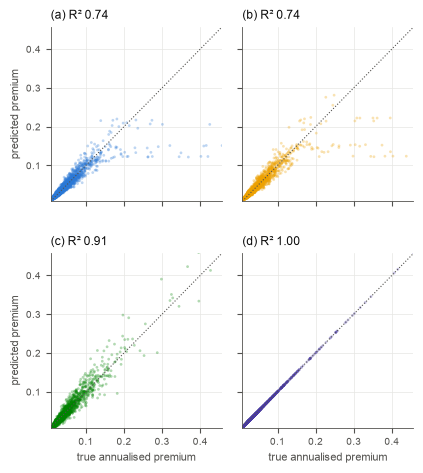

**Fig. 13** Predicted against true annualised premium under GARCH(1,1), pooled test windows. (a) Squared-error forest. (b) Merton-structural forest. (c) Merton formula on rolling volatility. (d) Merton formula on the true volatility (oracle)

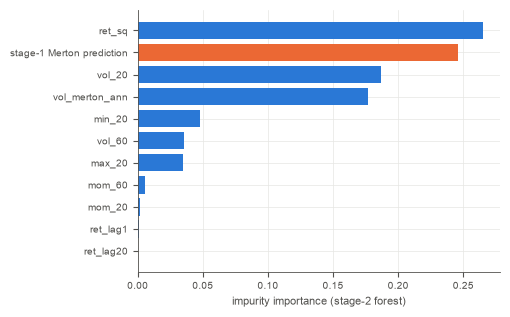

**Fig. 14** Impurity importance of the stage-2 features of the Merton-structural forest on one GARCH(1,1) series; the stage-1 Merton prediction is highlighted in orange

[  1315 s]


In [28]:
G = DAILY["GARCH(1,1)"]
fig, ax = plt.subplots(2, 2, figsize=(JW, 5.2), sharex=True, sharey=True)
ax = ax.ravel()
rng_ = np.random.default_rng(0)
for a, tag, k in zip(ax, "abcd", ["MSE", "Merton-structural", "Merton (rolling vol)", "Merton (oracle sigma)"]):
    p, yt = G["pooled"][k]
    idx = rng_.choice(len(p), min(2500, len(p)), replace=False)
    a.scatter(yt[idx], p[idx], s=4, alpha=0.3, color=COLOR_MODEL[k], edgecolor="none")
    lim = [min(yt.min(), p.min()), np.percentile(yt, 99.9)]
    a.plot(lim, lim, color=PAL["ink2"], lw=0.8, ls=":")
    a.set(title=f"({tag}) R² {G['summary'].loc[k, 'r2_pooled']:.2f}", xlim=lim, ylim=lim)
for a in ax[2:]:
    a.set_xlabel("true annualised premium")
for a in ax[::2]:
    a.set_ylabel("predicted premium")
fig.subplots_adjust(hspace=0.3, wspace=0.12)
savefig(fig, "fig13_premium_garch_pred_vs_true")

s_ = premium_garch(T=CFG["T_daily"], seed=99)
feats_, prem_, sig_, _ = prepare_premium_data(s_, 20, 60)
split_ = int(0.7 * len(feats_))
mstruct = MertonStructuralRF(list(feats_.columns).index(MERTON_VOL_COL), RFP).fit(feats_.values[:split_], prem_.values[:split_])
imp = pd.Series(mstruct.rf2.feature_importances_, index=list(feats_.columns) + ["stage-1 Merton prediction"]).sort_values()
fig, ax = plt.subplots(figsize=(JW, 3.4))
ax.barh(imp.index, imp.values, color=[PAL["orange"] if i == "stage-1 Merton prediction" else PAL["blue"] for i in imp.index])
ax.set(xlabel="impurity importance (stage-2 forest)")
savefig(fig, "fig14_premium_feature_importance")
print(elapsed())

## 10. Monthly frequency with persistent log-volatility: does persistence matter once realized volatility is observable?

kappa  0.5 (half-life  16.6 months)  SNR 2.02   R2 pooled: MSE +0.736  MAE +0.715  Huber +0.652  Merton-structural +0.741  SDF-weighted +0.745  Merton (rolling vol) +0.717   [  1434 s]


kappa  1.0 (half-life   8.3 months)  SNR 1.92   R2 pooled: MSE +0.738  MAE +0.711  Huber +0.643  Merton-structural +0.746  SDF-weighted +0.742  Merton (rolling vol) +0.725   [  1552 s]


kappa  2.0 (half-life   4.2 months)  SNR 1.72   R2 pooled: MSE +0.701  MAE +0.669  Huber +0.615  Merton-structural +0.709  SDF-weighted +0.702  Merton (rolling vol) +0.735   [  1691 s]


kappa  4.0 (half-life   2.1 months)  SNR 1.47   R2 pooled: MSE +0.679  MAE +0.648  Huber +0.602  Merton-structural +0.688  SDF-weighted +0.681  Merton (rolling vol) +0.733   [  1844 s]


half_life_months  r2_pooled  r2_median  \
kappa model                                                           
0.5   MSE                             16.6355     0.7358     0.7146   
      MAE                             16.6355     0.7152     0.7292   
      Huber                           16.6355     0.6515     0.6951   
      Merton-structural               16.6355     0.7413     0.7170   
      SDF-weighted                    16.6355     0.7454     0.7145   
      Merton (rolling vol)            16.6355     0.7172     0.5831   
      Merton (oracle sigma)           16.6355     1.0000     1.0000   
1.0   MSE                              8.3178     0.7382     0.7428   
      MAE                              8.3178     0.7111     0.7404   
      Huber                            8.3178     0.6430     0.7004   
      Merton-structural                8.3178     0.7456     0.7418   
      SDF-weighted                     8.3178     0.7418     0.7318   
      Merton (rolling vol)             8.3178     0.7250     0.6186   
      Merton (oracle sigma)            8.3178     0.9999     0.9999   
2.0   MSE                              4.1589     0.7008     0.7393   
      MAE                              4.1589     0.6687     0.7403   
      Huber                            4.1589     0.6146     0.7215   
      Merton-structural                4.1589     0.7086     0.7434   
      SDF-weighted                     4.1589     0.7017     0.7287   
      Merton (rolling vol)             4.1589     0.7347     0.6739   
      Merton (oracle sigma)            4.1589     0.9998     0.9998   
4.0   MSE                              2.0794     0.6794     0.7183   
      MAE                              2.0794     0.6477     0.6993   
      Huber                            2.0794     0.6021     0.6621   
      Merton-structural                2.0794     0.6879     0.7250   
      SDF-weighted                     2.0794     0.6812     0.7202   
      Merton (rolling vol)             2.0794     0.7326     0.7054   
      Merton (oracle sigma)            2.0794     0.9992     0.9992   

                             rmse_mean  bias_mean  
kappa model                                        
0.5   MSE                       0.0345    -0.0023  
      MAE                       0.0353    -0.0061  
      Huber                     0.0385    -0.0067  
      Merton-structural         0.0342    -0.0023  
      SDF-weighted              0.0341    -0.0020  
      Merton (rolling vol)      0.0384     0.0005  
      Merton (oracle sigma)     0.0003    -0.0002  
1.0   MSE                       0.0358    -0.0003  
      MAE                       0.0369    -0.0051  
      Huber                     0.0403    -0.0051  
      Merton-structural         0.0354    -0.0002  
      SDF-weighted              0.0357     0.0007  
      Merton (rolling vol)      0.0388     0.0004  
      Merton (oracle sigma)     0.0005    -0.0003  
2.0   MSE                       0.0382     0.0005  
      MAE                       0.0397    -0.0050  
      Huber                     0.0426    -0.0047  
      Merton-structural         0.0377     0.0004  
      SDF-weighted              0.0383     0.0019  
      Merton (rolling vol)      0.0384     0.0002  
      Merton (oracle sigma)     0.0010    -0.0007  
4.0   MSE                       0.0399     0.0003  
      MAE                       0.0416    -0.0055  
      Huber                     0.0443    -0.0050  
      Merton-structural         0.0393     0.0003  
      SDF-weighted              0.0400     0.0020  
      Merton (rolling vol)      0.0383     0.0001  
      Merton (oracle sigma)     0.0020    -0.0013

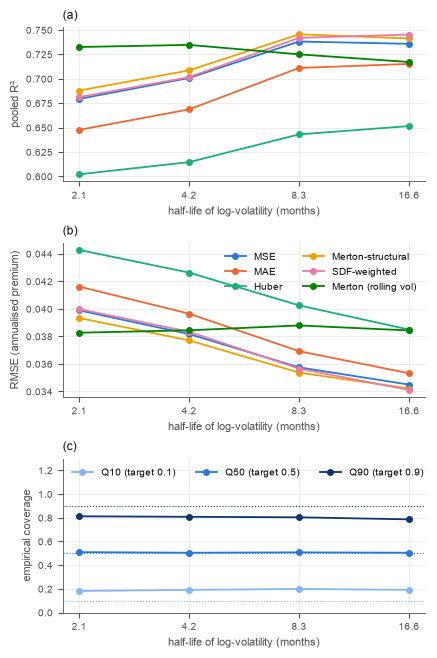

**Fig. 15** Premium recovery at monthly frequency with log-volatility Ornstein-Uhlenbeck dynamics. (a) Pooled R squared against the half-life of log-volatility. (b) Root mean squared error. (c) Empirical coverage of the quantile models; dotted lines are the targets

In [29]:
MONTHLY = {}
for kappa in CFG["kappas"]:
    gen = (lambda kappa: (lambda T, seed: premium_ou_logvol(T, seed, kappa=kappa)))(kappa)
    MONTHLY[kappa] = run_premium_experiment(gen, n_reps=CFG["n_reps_monthly"], monthly=True, T=CFG["T_monthly"], params=RFP)
    print(f"kappa {kappa:4.1f} (half-life {math.log(2) / kappa * 12:5.1f} months)  SNR {MONTHLY[kappa]['signal_to_noise']:.2f}   R2 pooled: " +
          "  ".join(f"{k} {MONTHLY[kappa]['summary'].loc[k, 'r2_pooled']:+.3f}" for k in ["MSE", "MAE", "Huber", "Merton-structural", "SDF-weighted", "Merton (rolling vol)"]) + f"   {elapsed()}")
monthly_tbl = pd.concat([d["summary"].assign(kappa=k, half_life_months=math.log(2) / k * 12) for k, d in MONTHLY.items()]).reset_index().set_index(["kappa", "model"])
save_table(monthly_tbl, "table_premium_monthly")
monthly_q = pd.concat([d["quantile_summary"].assign(kappa=k) for k, d in MONTHLY.items()]).reset_index().set_index(["kappa", "model"])
save_table(monthly_q, "table_premium_monthly_quantiles")
display(monthly_tbl[["half_life_months", "r2_pooled", "r2_median", "rmse_mean", "bias_mean"]].round(4))

hl = [math.log(2) / k * 12 for k in MONTHLY]
fig, ax = plt.subplots(3, 1, figsize=(JW, 7.6))
for k in MEAN_MODELS[:6]:
    ax[0].plot(hl, [MONTHLY[kp]["summary"].loc[k, "r2_pooled"] for kp in MONTHLY], marker="o", color=COLOR_MODEL[k], label=k)
    ax[1].plot(hl, [MONTHLY[kp]["summary"].loc[k, "rmse_mean"] for kp in MONTHLY], marker="o", color=COLOR_MODEL[k], label=k)
ax[0].set(title="(a)", xlabel="half-life of log-volatility (months)", ylabel="pooled R²", xscale="log")
ax[1].set(title="(b)", xlabel="half-life of log-volatility (months)", ylabel="RMSE (annualised premium)", xscale="log")
ax[1].legend(loc="upper right", ncol=2)
for q in ["Q10", "Q50", "Q90"]:
    ax[2].plot(hl, [MONTHLY[kp]["quantile_summary"].loc[q, "coverage"] for kp in MONTHLY], marker="o", color=COLOR_Q[q], label=f"{q} (target {QUANT_MODELS[q]:.1f})")
    ax[2].axhline(QUANT_MODELS[q], color=COLOR_Q[q], lw=0.8, ls=":")
ax[2].set(title="(c)", xlabel="half-life of log-volatility (months)", ylabel="empirical coverage", xscale="log", ylim=(0, 1.3))
ax[2].legend(loc="upper left", ncol=3)
for a in ax:
    a.set_xticks(hl); a.set_xticklabels([f"{h:.1f}" for h in hl]); a.minorticks_off()
fig.subplots_adjust(hspace=0.4)
savefig(fig, "fig15_premium_monthly")

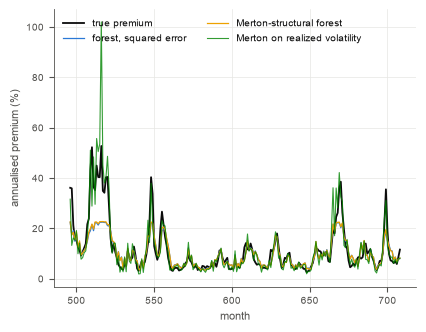

**Fig. 16** Test window of one monthly realisation (kappa = 2): true annualised premium against the nowcasts of the squared-error forest, the Merton-structural forest and the Merton formula on realized volatility

[  1852 s]


In [30]:
kappa_ts = 2.0 if 2.0 in MONTHLY else list(MONTHLY)[-1]
s_m = aggregate_monthly(premium_ou_logvol(T=CFG["T_monthly"], seed=4242, kappa=kappa_ts))
feats_m, prem_m, sig_m, _ = prepare_premium_data(s_m, 3, 12)
X_m, y_m = feats_m.values, prem_m.values
split_m = int(0.7 * len(X_m))
vol_col_m = list(feats_m.columns).index(MERTON_VOL_COL)
rf_mse_m = fit_rf(X_m[:split_m], y_m[:split_m], params=RFP)
mer_m = MertonStructuralRF(vol_col_m, RFP).fit(X_m[:split_m], y_m[:split_m])
tt = np.arange(split_m, len(X_m))
fig, ax = plt.subplots(figsize=(JW, 3.6))
ax.plot(tt, y_m[split_m:] * 100, color=PAL["ink"], lw=1.3, label="true premium")
ax.plot(tt, rf_mse_m.predict(X_m[split_m:]) * 100, color=COLOR_MODEL["MSE"], lw=0.9, label="forest, squared error")
ax.plot(tt, mer_m.predict(X_m[split_m:]) * 100, color=COLOR_MODEL["Merton-structural"], lw=0.9, label="Merton-structural forest")
ax.plot(tt, merton_from_vol(X_m[split_m:, vol_col_m]) * 100, color=COLOR_MODEL["Merton (rolling vol)"], lw=0.8, alpha=0.8, label="Merton on realized volatility")
ax.set(xlabel="month", ylabel="annualised premium (%)")
ax.legend(loc="upper left", ncol=2)
savefig(fig, "fig16_premium_monthly_timeseries")
print(elapsed())

# 11. Verification and consolidated findings

The unit tests are executed from inside the notebook so the reported numbers and the tested code
are the same artefact. The findings paragraph is generated from the objects computed above.

In [31]:
tests_dir = pathlib.Path("tests")
if tests_dir.exists():
    proc = subprocess.run([sys.executable, "-m", "pytest", str(tests_dir), "-q", "--no-header", "-p", "no:cacheprovider"], capture_output=True, text=True)
    TEST_OUTPUT = (proc.stdout + proc.stderr).strip().splitlines()
    print("\n".join(TEST_OUTPUT[-12:]))
    TESTS_PASSED = proc.returncode == 0
else:
    TESTS_PASSED, TEST_OUTPUT = None, ["tests/ not found next to the notebook"]
    print(TEST_OUTPUT[0])
print(elapsed())

........................................................................ [ 91%]
.......                                                                  [100%]
============================== warnings summary ===============================
tests/test_mmlab.py::TestEvaluation::test_paired_test_matches_scipy_and_edge_cases
  C:\Users\kosteriillia\.venvs\mmlab\Lib\site-packages\scipy\stats\_axis_nan_policy.py:431: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
    return hypotest_fun_in(*args, **kwds)

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
79 passed, 1 warning in 22.72s
[  1876 s]


**Verification.** All unit tests passed. Run mode: full publication settings. Wall time 1876 s.

**Exact inverse.** Re-optimising the KKT implied returns reproduces the weights to 9e-16 (level-shift family: 6e-15); the exact-inverse null test gives t = 0.50 (mean difference +6e-20) on 400 universes and never exceeds |t| = 1.87 across DGPs.

**Learnability.** Under the baseline cap c = 0.5 the surrogate reaches classification accuracy 0.977 and R² 0.814; across the cap sweep accuracy runs from 0.961 to 0.980 and R² from 0.543 to 0.891 while the binding share falls from 61 to 17 percent: loosening the floor makes the inverse smoother and easier to learn.

**Decision value.** On Gaussian GBM markets the surrogate beats the two-stage pipeline out of sample: mean utility gain +2.26e-04 (95% CI +1.91e-04 to +2.61e-04), t = 12.7, p = <1e-16, win rate 81%; volatility-matched Newey-West t = 4.6. The gain is significant at every risk aversion after Bonferroni correction (eta in 1, 2, 5, 10, 20; smallest t = 2.48 at eta = 1).

**Robustness.** Across the non-Gaussian and correlated DGPs the paired t statistic ranges from 9.3 (One-factor) to 15.3 (Skew-normal) with win rates 70 to 85%. Estimating on simple rather than log returns raises realised arithmetic utility for the two-stage pipeline (t = +3.88, p = 6.36e-05) and raises it for the surrogate (t = +3.00); the de-meaned implied-return patterns of the two panels correlate at 0.985. With identical mean and variance, skew-normal markets change the per-universe dispersion of implied returns only marginally (KS D = 0.062, p = 0.292).

**Utility mismatch.** MV and CRRA implied returns coincide on gamma = 2 eta (correlation 0.982 or higher in every DGP) and separate off it (minimum correlation 0.60; std ratio between 0.29 and 17.9). The corner-fraction mismatch predicts the divergence (Pearson 0.73, Spearman 0.74), while the raw CRRA corner share does not (Pearson 0.42).

**Premium recovery, daily.** With i.i.d. volatility no learned model recovers the premium (best pooled R² -0.003; negative control as intended). Under GARCH(1,1) the forests reach R² 0.68 to 0.74 (SDF-weighted best); the feasible Merton formula on rolling volatility gives 0.91. The loss function matters far less than whether volatility is persistent.

**Premium recovery, monthly.** With realized volatility observable inside the month, pooled R² lies between 0.60 and 0.75 for every half-life from 2.1 to 16.6 months; the spread across loss functions at a given half-life is at most 0.13 R² points. The Merton-structural forest beats the squared-error forest, and the SDF-weighted forest beats it. Economic structure helps at the margin at best once the observable volatility is in the feature set.

C:\Users\kosteriillia\AppData\Local\Temp\ipykernel_224696\4028134847.py:37: ResourceWarning: unclosed file <_io.TextIOWrapper name='outputs\\headline_results.json' mode='w' encoding='cp65001'>
  json.dump(dict(reopt_err=REOPT_ERR, family_err=FAMILY_ERR, main=MAIN["main"], null=MAIN["null"], newey_west=nw, tests_passed=TESTS_PASSED, fast=FAST,


## 12. Limitations and scope

* **Synthetic markets.** Every DGP is simulated; parameter ranges (drift up to 100 percent, volatility
  up to 100 percent per year) follow the source notebooks and are wide. Real-data validation is
  future work.
* **The surrogate is a supervised shortcut.** It learns the closed-form inverse from other universes
  and is *evaluated* with the decision loss; it does not back-propagate the decision loss through a
  differentiable optimisation layer as in the end-to-end model of Wang, Gao, Harvey, Liu and Tao
  (2026). Its out-of-sample gain is a learned shrinkage of noisy sample means, which is exactly why it
  cannot be distinguished from a well-tuned shrinkage estimator without further experiments.
* **Gauge.** Implied-return levels are not identified; every level-dependent statement (means,
  absolute levels in figures) is conditional on the mean-variance budget dual.
* **Nowcast, not forecast.** Part II recovers the contemporaneous premium from returns up to and
  including the same period, as the source notebooks did. A one-period-ahead forecast would be a
  different, harder task.
* **Heuristic SDF weighting.** The Euler-residual weights of the 8th step are a heuristic, not a
  pricing-kernel estimate, and are kept for comparability only.
* **Multiple testing.** The eta sweep is Bonferroni-corrected; the robustness table across DGPs is
  not, but all of its p-values are far below any reasonable family-wise threshold.

## Reproducibility

`mmlab.py` is the single source of truth; `build_notebook.py` embeds it into this notebook and
`tests/test_mmlab.py` verifies both the numerical properties (exact inverse, feasibility, level
invariance, feature causality, model APIs) and the identity between embedded and tested code.
Random seeds are fixed everywhere; the training seeds (0 to 119) and the evaluation seeds (1000 and
up) never overlap. Outputs: `outputs/*.png|pdf` (figures), `outputs/*.csv` (tables),
`outputs/headline_results.json` (numbers quoted in Section 11).